In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                           roc_auc_score, confusion_matrix, classification_report,
                           matthews_corrcoef, brier_score_loss, cohen_kappa_score,
                           log_loss, balanced_accuracy_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import time
import warnings

# Menekan warning
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
# Download dataset from Google Drive
print("Downloading dataset...")
file_id = "1uqWw4zeSXKXW6JC9c6mQSAOibDNNqb6Y"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "Diabetes_Final_Data_V2.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1uqWw4zeSXKXW6JC9c6mQSAOibDNNqb6Y
To: /content/Diabetes_Final_Data_V2.csv
100%|██████████| 288k/288k [00:00<00:00, 31.0MB/s]


'Diabetes_Final_Data_V2.csv'

In [ ]:
# Load data
print("Loading data...")
df = pd.read_csv("Diabetes_Final_Data_V2.csv")

Loading data...


In [ ]:
# Menyimpan salinan data asli
df_original = df.copy()

In [ ]:
# EDA dasar
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5437 entries, 0 to 5436
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5437 non-null   int64  
 1   gender                  5437 non-null   object 
 2   pulse_rate              5437 non-null   int64  
 3   systolic_bp             5437 non-null   int64  
 4   diastolic_bp            5437 non-null   int64  
 5   glucose                 5437 non-null   float64
 6   height                  5437 non-null   float64
 7   weight                  5437 non-null   float64
 8   bmi                     5437 non-null   float64
 9   family_diabetes         5437 non-null   int64  
 10  hypertensive            5437 non-null   int64  
 11  family_hypertension     5437 non-null   int64  
 12  cardiovascular_disease  5437 non-null   int64  
 13  stroke                  5437 non-null   int64  
 14  diabetic          

In [ ]:
def visualize_original_data(df):
    # Cek missing values
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        plt.figure(figsize=(12, 6))
        missing.sort_values(ascending=False).plot.bar()
        plt.title('Missing Values dalam Dataset Original')
        plt.xlabel('Kolom')
        plt.ylabel('Jumlah Missing Values')
        plt.tight_layout()
        plt.show()
    else:
        print("Tidak ada missing values dalam dataset original.")

visualize_original_data(df_original)

Tidak ada missing values dalam dataset original.


In [ ]:
#------------------------------------------------------
# 2. Visualisasi Setelah Encoding
#------------------------------------------------------

VISUALISASI SETELAH ENCODING


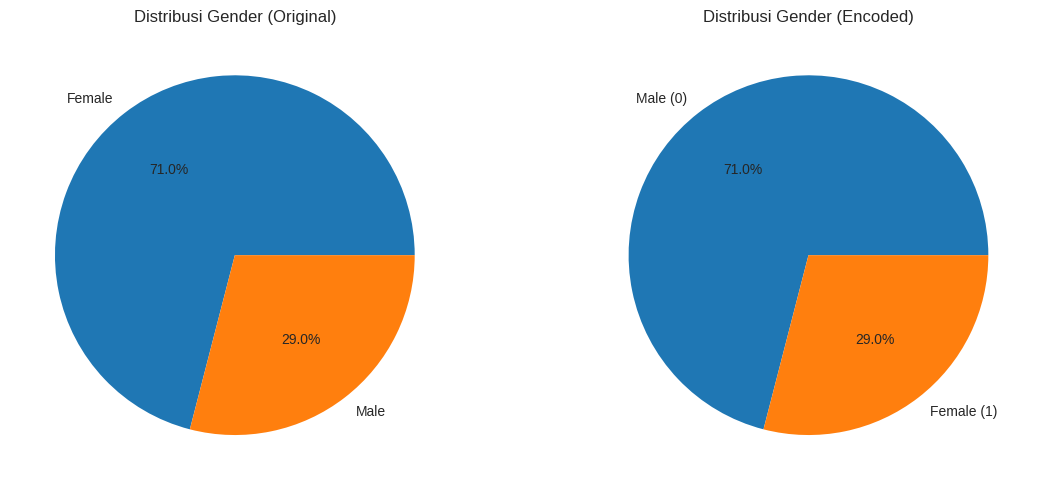

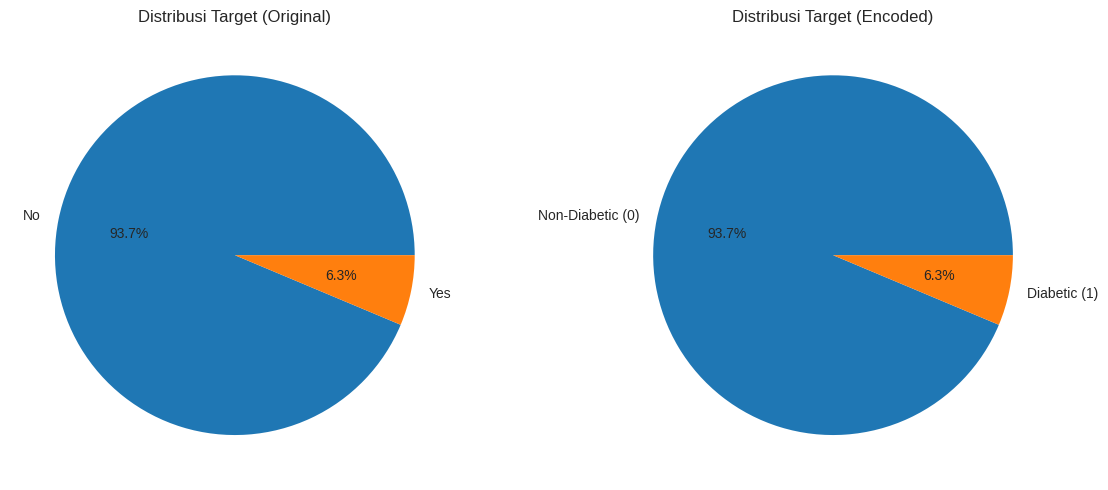

In [ ]:
def visualize_after_encoding(df_original):
    print("=" * 50)
    print("VISUALISASI SETELAH ENCODING")
    print("=" * 50)

    # Buat salinan dan lakukan encoding
    df_encoded = df_original.copy()

    # Encoding gender
    from sklearn.preprocessing import LabelEncoder
    gender_encoder = LabelEncoder()
    df_encoded['gender_encoded'] = gender_encoder.fit_transform(df_encoded['gender'])

    # Encoding target
    target_encoder = LabelEncoder()
    df_encoded['diabetic_encoded'] = target_encoder.fit_transform(df_encoded['diabetic'])

    # Tampilkan hasil encoding gender
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    gender_counts = df_encoded['gender'].value_counts()
    plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
    plt.title('Distribusi Gender (Original)')

    plt.subplot(1, 2, 2)
    encoded_counts = df_encoded['gender_encoded'].value_counts()
    plt.pie(encoded_counts, labels=['Male (0)', 'Female (1)'], autopct='%1.1f%%')
    plt.title('Distribusi Gender (Encoded)')

    plt.tight_layout()
    plt.show()

    # Tampilkan hasil encoding target
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    target_counts = df_encoded['diabetic'].value_counts()
    plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%')
    plt.title('Distribusi Target (Original)')

    plt.subplot(1, 2, 2)
    encoded_target_counts = df_encoded['diabetic_encoded'].value_counts()
    plt.pie(encoded_target_counts, labels=['Non-Diabetic (0)', 'Diabetic (1)'], autopct='%1.1f%%')
    plt.title('Distribusi Target (Encoded)')

    plt.tight_layout()
    plt.show()

    return df_encoded

df_encoded = visualize_after_encoding(df_original)

VISUALISASI SETELAH FEATURE ENGINEERING


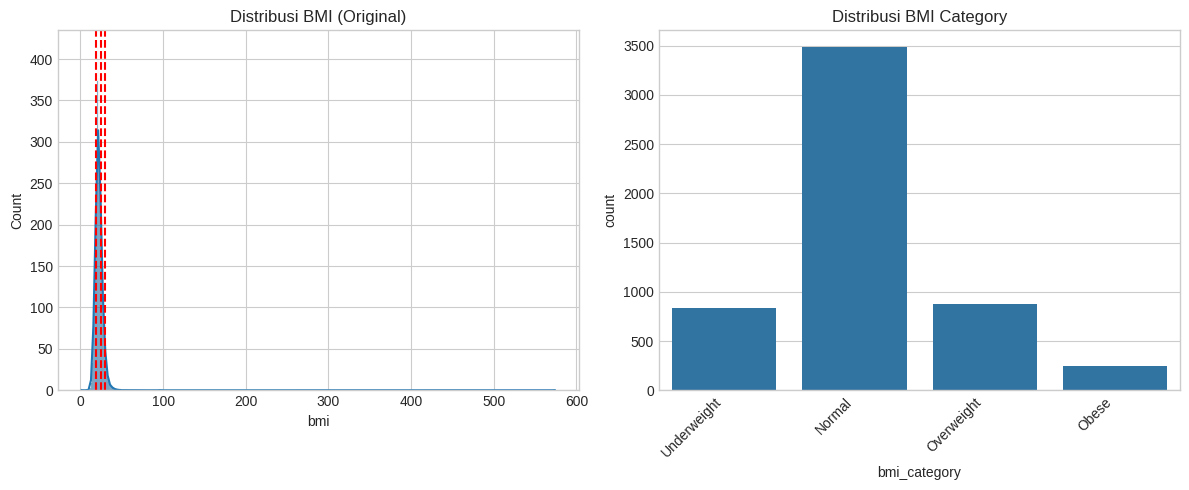

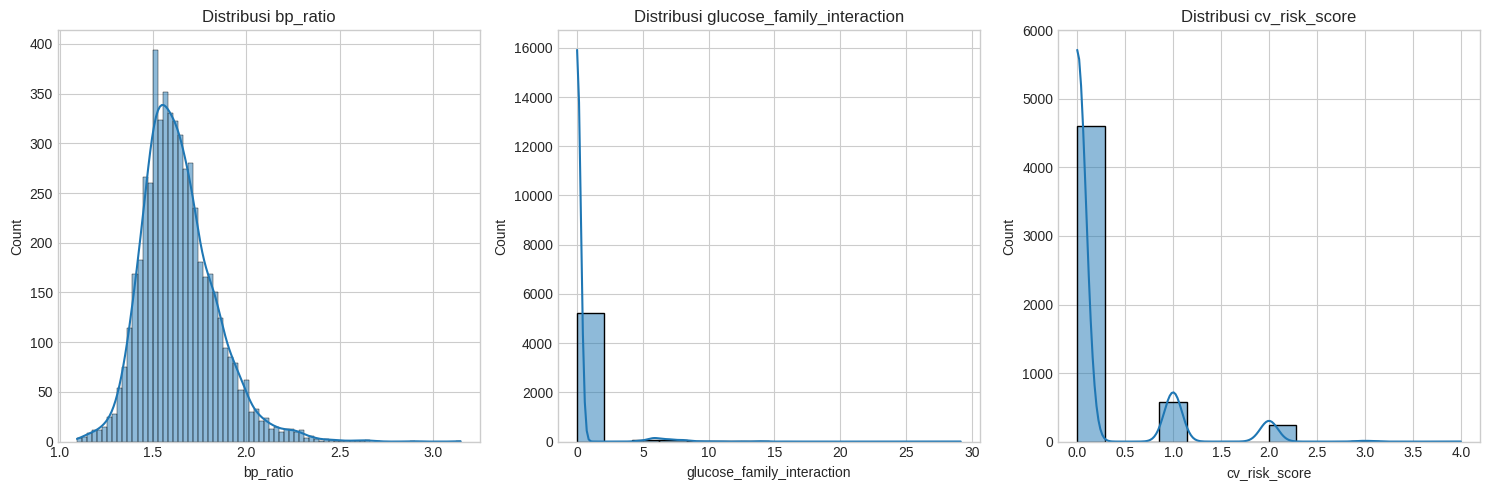

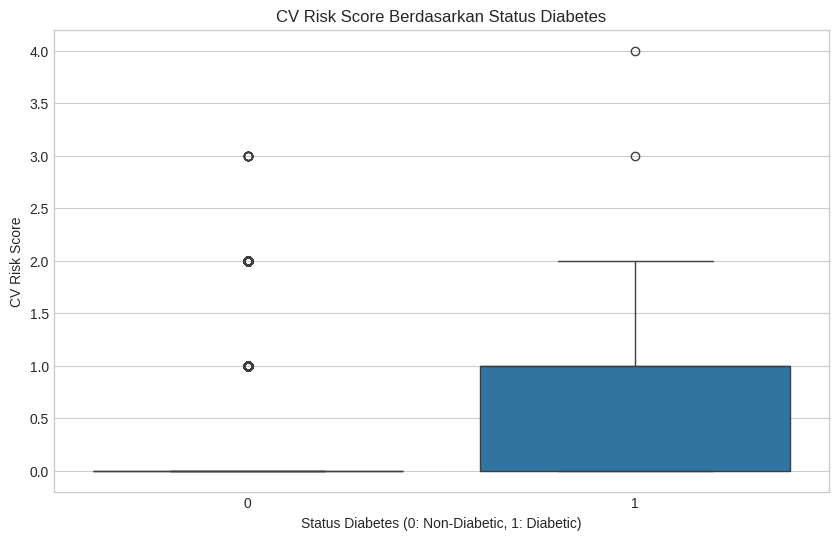

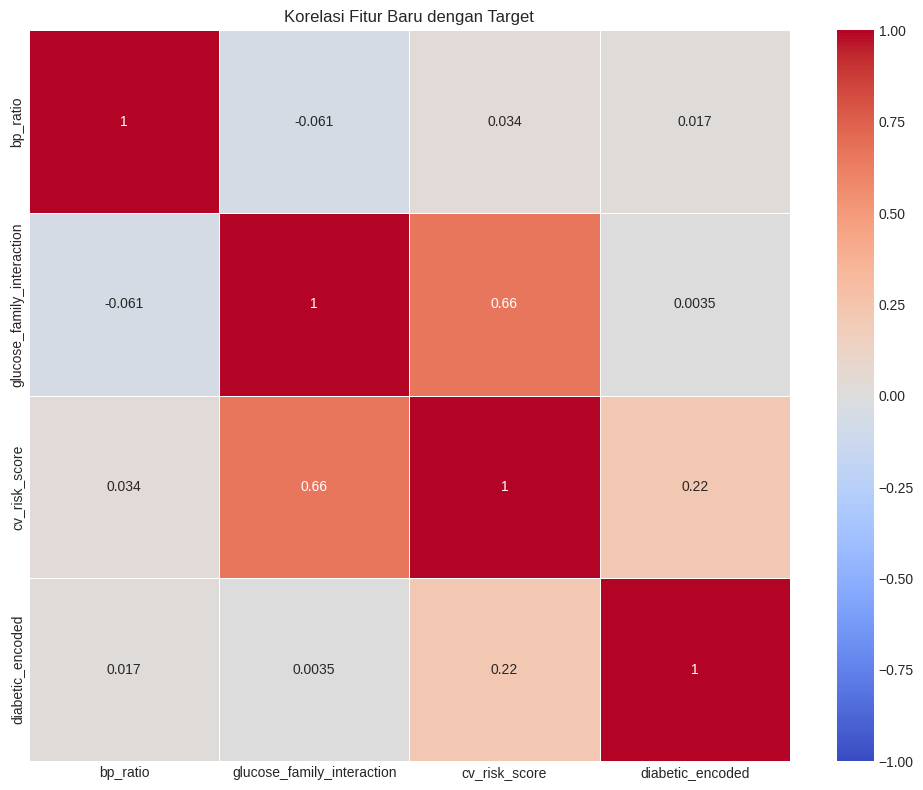

In [ ]:
def visualize_after_feature_engineering(df_encoded):
    print("=" * 50)
    print("VISUALISASI SETELAH FEATURE ENGINEERING")
    print("=" * 50)

    # Buat salinan dan lakukan feature engineering
    df_fe = df_encoded.copy()

    # BMI kategori
    df_fe['bmi_category'] = pd.cut(df_fe['bmi'],
                              bins=[0, 18.5, 25, 30, 100],
                              labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
    df_fe['bmi_category_encoded'] = df_fe['bmi_category'].cat.codes

    # Rasio tekanan darah
    df_fe['bp_ratio'] = df_fe['systolic_bp'] / df_fe['diastolic_bp']

    # Interaksi glucose dengan riwayat keluarga
    df_fe['glucose_family_interaction'] = df_fe['glucose'] * df_fe['family_diabetes']

    # Risk score
    risk_factors = ['hypertensive', 'family_hypertension', 'cardiovascular_disease', 'stroke', 'family_diabetes']
    df_fe['cv_risk_score'] = df_fe[risk_factors].sum(axis=1)

    # Visualisasi distribusi BMI kategori
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df_fe['bmi'], kde=True)
    plt.axvline(x=18.5, color='r', linestyle='--')
    plt.axvline(x=25, color='r', linestyle='--')
    plt.axvline(x=30, color='r', linestyle='--')
    plt.title('Distribusi BMI (Original)')

    plt.subplot(1, 2, 2)
    sns.countplot(x='bmi_category', data=df_fe)
    plt.xticks(rotation=45, ha='right')
    plt.title('Distribusi BMI Category')

    plt.tight_layout()
    plt.show()

    # Visualisasi fitur baru
    new_features = ['bp_ratio', 'glucose_family_interaction', 'cv_risk_score']
    plt.figure(figsize=(15, 5))

    for i, feature in enumerate(new_features):
        plt.subplot(1, 3, i+1)
        sns.histplot(df_fe[feature], kde=True)
        plt.title(f'Distribusi {feature}')

    plt.tight_layout()
    plt.show()

    # Visualisasi cv_risk_score berdasarkan status diabetes
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='diabetic_encoded', y='cv_risk_score', data=df_fe)
    plt.title('CV Risk Score Berdasarkan Status Diabetes')
    plt.xlabel('Status Diabetes (0: Non-Diabetic, 1: Diabetic)')
    plt.ylabel('CV Risk Score')
    plt.show()

    # Visualisasi korelasi antara fitur baru dengan target
    new_features_with_target = new_features + ['diabetic_encoded']
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_fe[new_features_with_target].corr(), annot=True, cmap='coolwarm',
                vmin=-1, vmax=1, linewidths=0.5)
    plt.title('Korelasi Fitur Baru dengan Target')
    plt.tight_layout()
    plt.show()

    return df_fe

df_fe = visualize_after_feature_engineering(df_encoded)

VISUALISASI SETELAH PENANGANAN MISSING VALUES


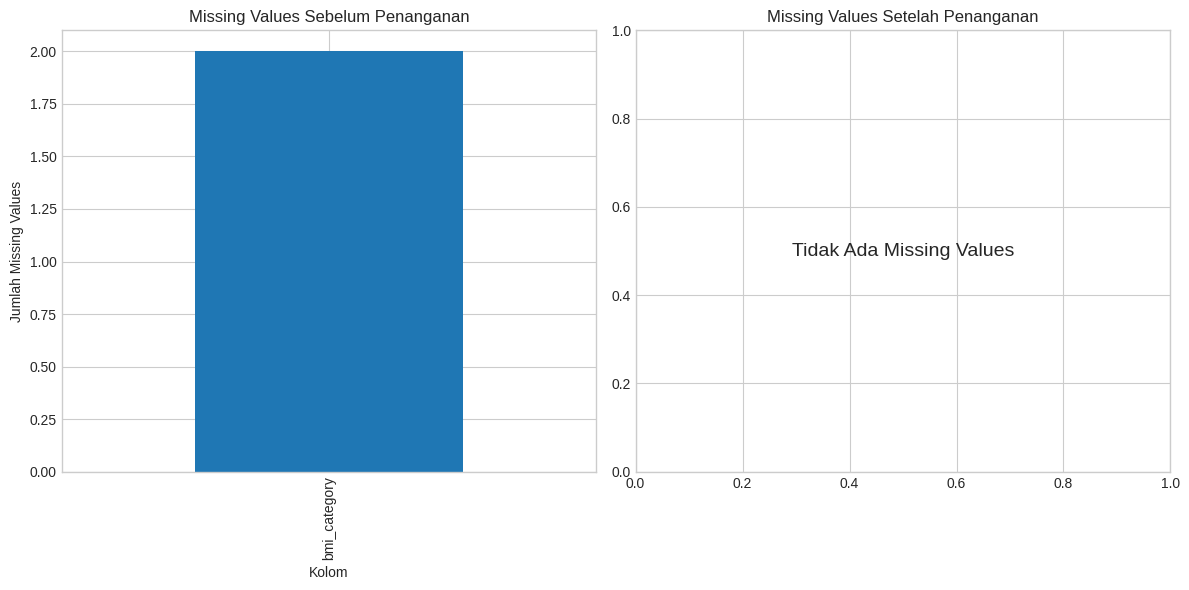

In [ ]:
def visualize_after_missing_values(df_fe):
    print("=" * 50)
    print("VISUALISASI SETELAH PENANGANAN MISSING VALUES")
    print("=" * 50)

    # Buat salinan
    df_no_missing = df_fe.copy()

    # Cek missing values sebelum penanganan
    missing_before = df_no_missing.isnull().sum()
    missing_before = missing_before[missing_before > 0]

    # Tangani missing values
    for col in df_no_missing.columns:
        if df_no_missing[col].isnull().sum() > 0:
            if df_no_missing[col].dtype in ['int64', 'float64']:
                skewness = df_no_missing[col].skew()
                if abs(skewness) > 1:
                    df_no_missing[col].fillna(df_no_missing[col].median(), inplace=True)
                else:
                    df_no_missing[col].fillna(df_no_missing[col].mean(), inplace=True)
            else:
                df_no_missing[col].fillna(df_no_missing[col].mode()[0], inplace=True)

    # Cek missing values setelah penanganan
    missing_after = df_no_missing.isnull().sum()
    missing_after = missing_after[missing_after > 0]

    # Visualisasi perbandingan sebelum dan sesudah
    if len(missing_before) > 0:
        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)
        missing_before.sort_values(ascending=False).plot.bar()
        plt.title('Missing Values Sebelum Penanganan')
        plt.xlabel('Kolom')
        plt.ylabel('Jumlah Missing Values')

        plt.subplot(1, 2, 2)
        if len(missing_after) > 0:
            missing_after.sort_values(ascending=False).plot.bar()
            plt.title('Missing Values Setelah Penanganan')
            plt.xlabel('Kolom')
            plt.ylabel('Jumlah Missing Values')
        else:
            plt.text(0.5, 0.5, 'Tidak Ada Missing Values',
                     horizontalalignment='center', verticalalignment='center',
                     transform=plt.gca().transAxes, fontsize=14)
            plt.title('Missing Values Setelah Penanganan')

        plt.tight_layout()
        plt.show()
    else:
        print("Tidak ada missing values dalam dataset sebelum penanganan.")

    # Visualisasi distribusi kolom numerik yang mungkin memiliki missing values
    numeric_cols = ['age', 'pulse_rate', 'systolic_bp', 'diastolic_bp',
                    'glucose', 'height', 'weight', 'bmi']

    # Bandingkan distribusi sebelum dan sesudah (jika ada missing values)
    if len(missing_before) > 0:
        for col in numeric_cols:
            if col in missing_before.index:
                plt.figure(figsize=(12, 5))

                plt.subplot(1, 2, 1)
                sns.histplot(df_fe[col], kde=True)
                plt.title(f'Distribusi {col} (Dengan Missing Values)')

                plt.subplot(1, 2, 2)
                sns.histplot(df_no_missing[col], kde=True)
                plt.title(f'Distribusi {col} (Setelah Penanganan)')

                plt.tight_layout()
                plt.show()

    return df_no_missing

df_no_missing = visualize_after_missing_values(df_fe)

VISUALISASI SETELAH PENANGANAN OUTLIER
Outliers in age: 23


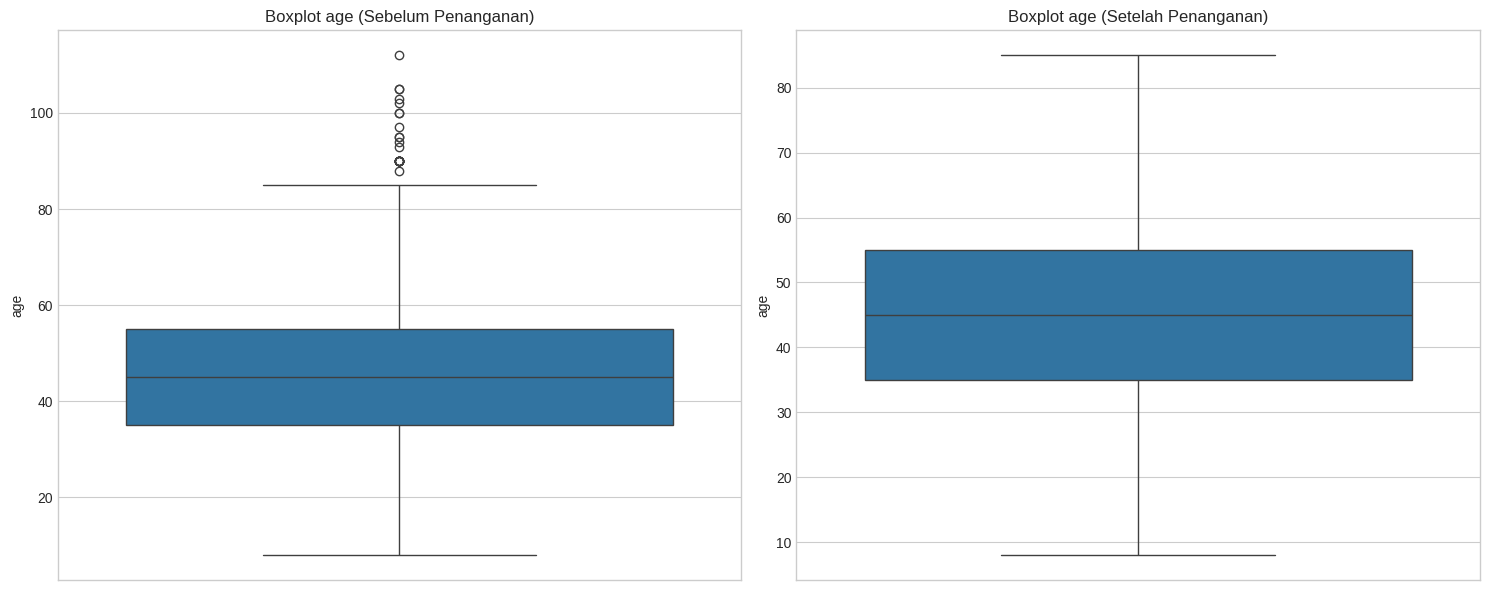

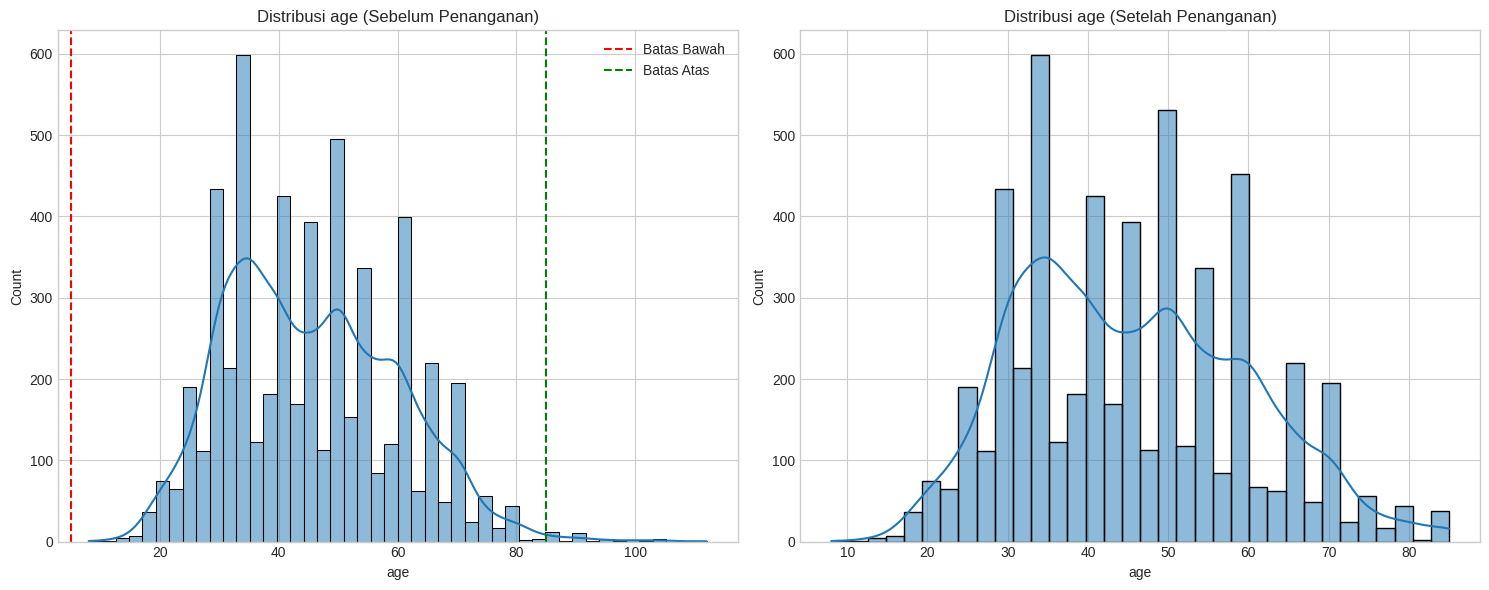

Outliers in pulse_rate: 102


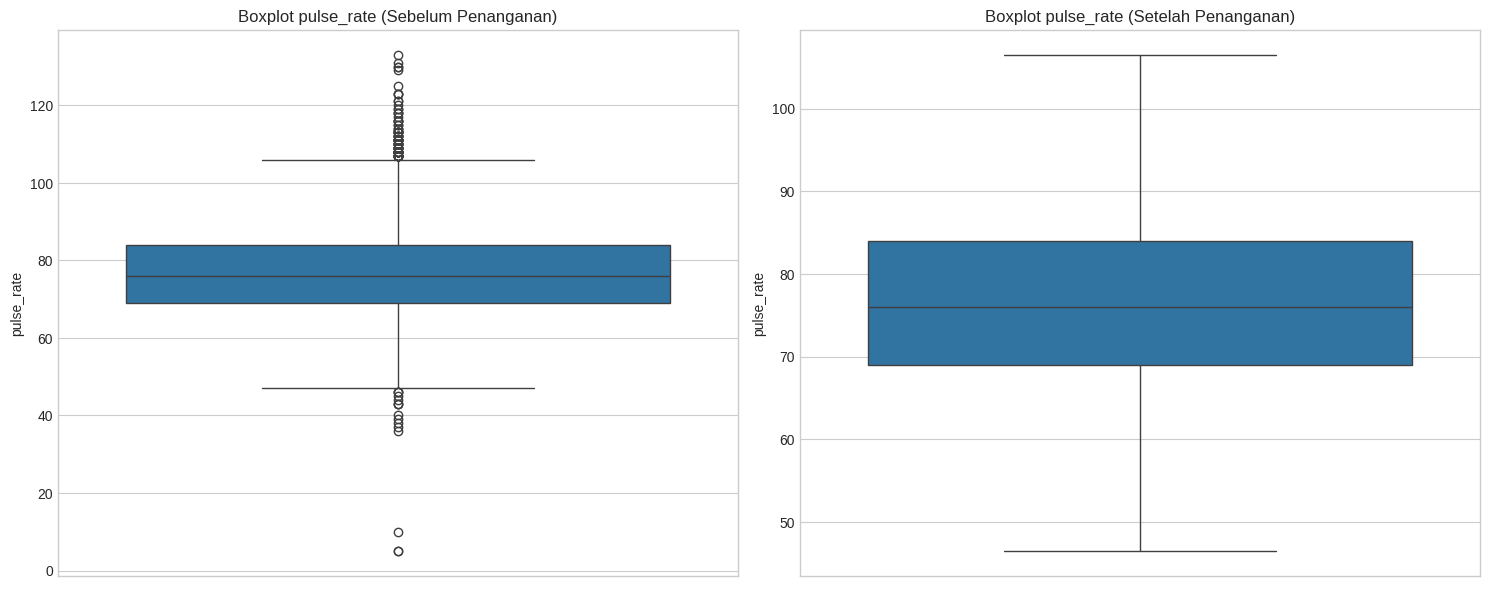

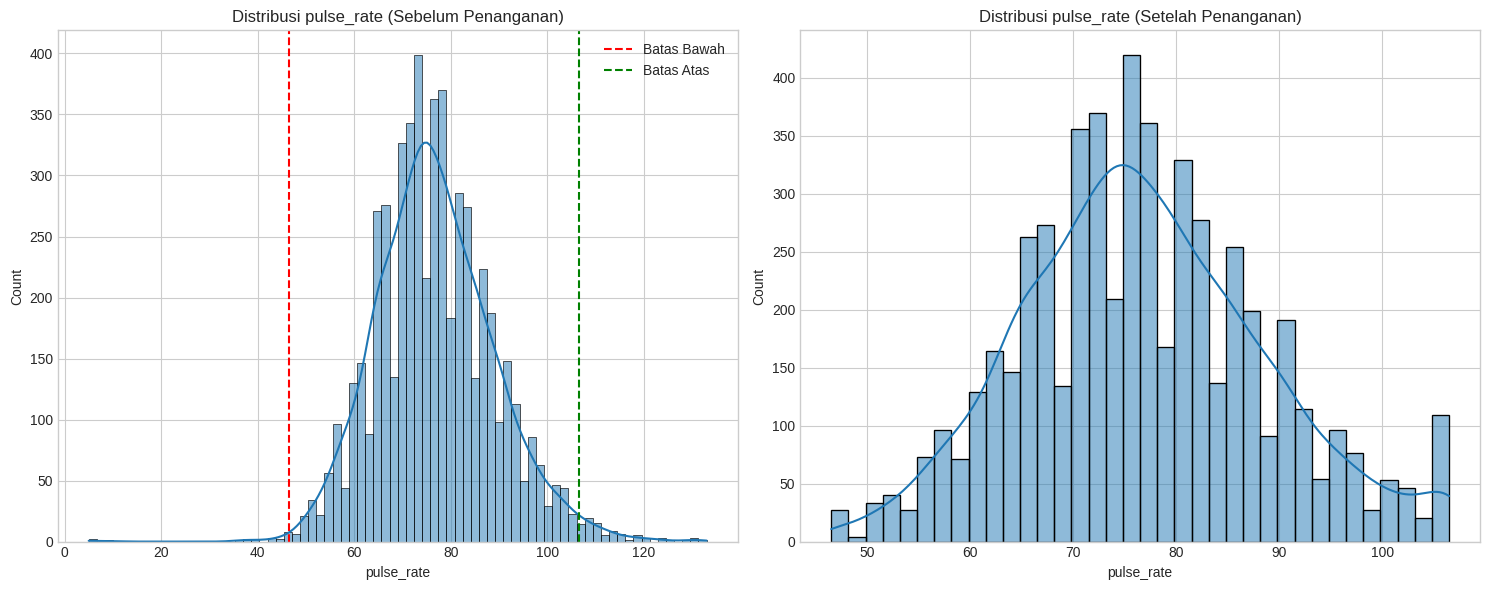

Outliers in systolic_bp: 118


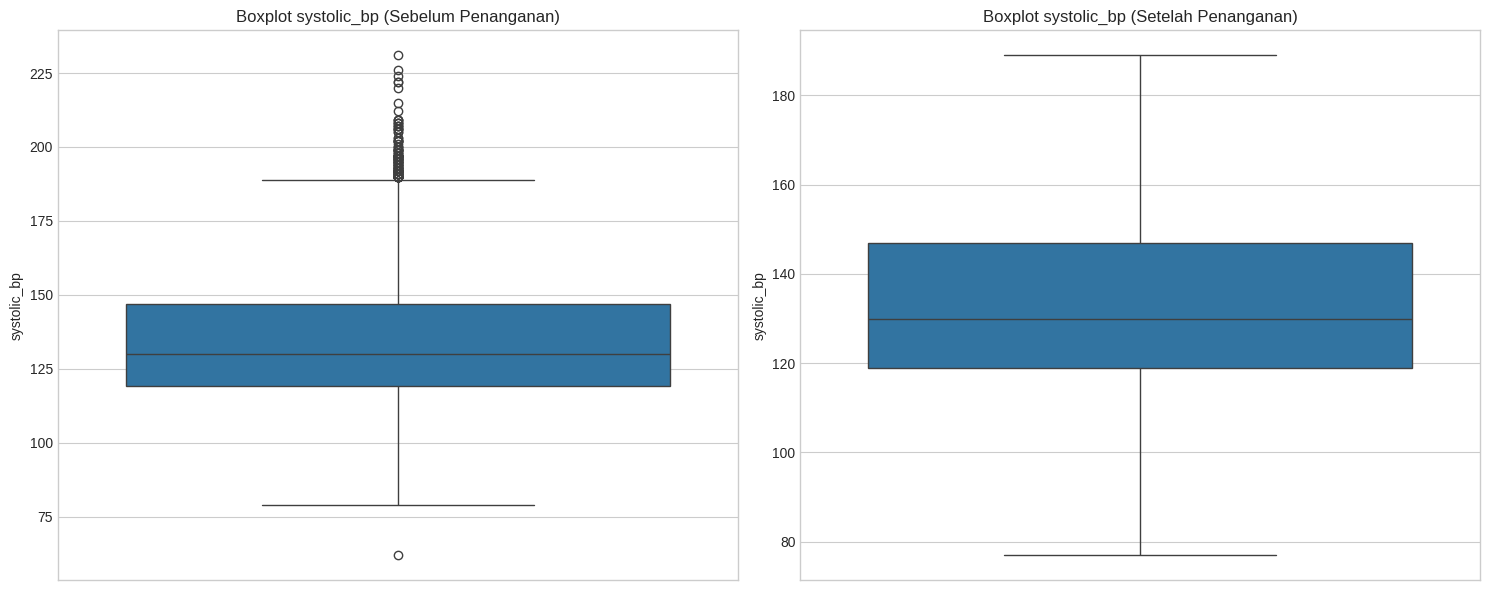

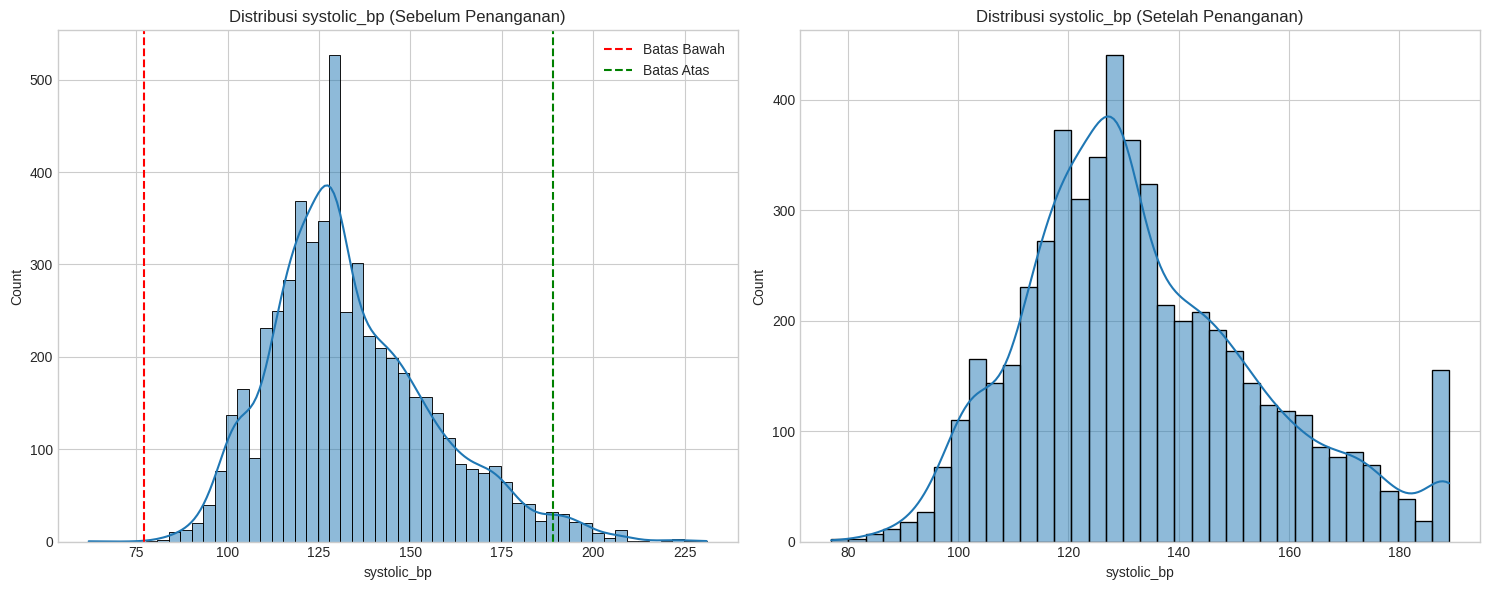

Outliers in diastolic_bp: 54


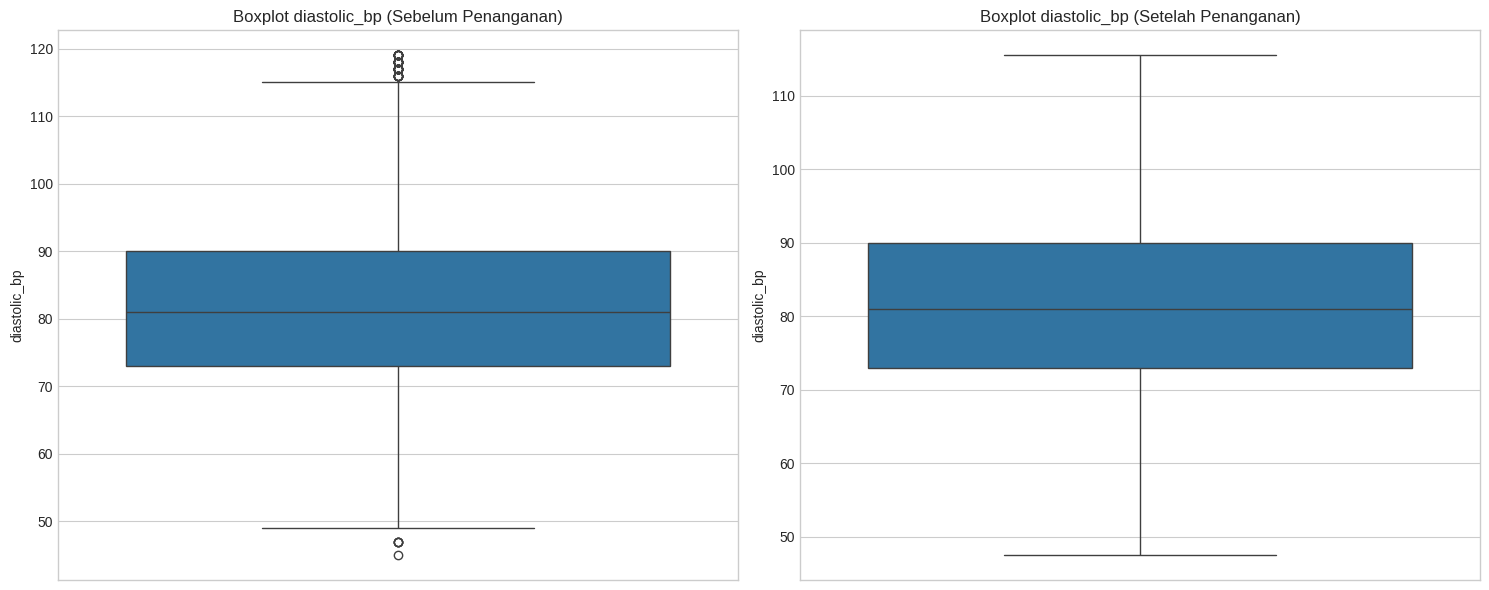

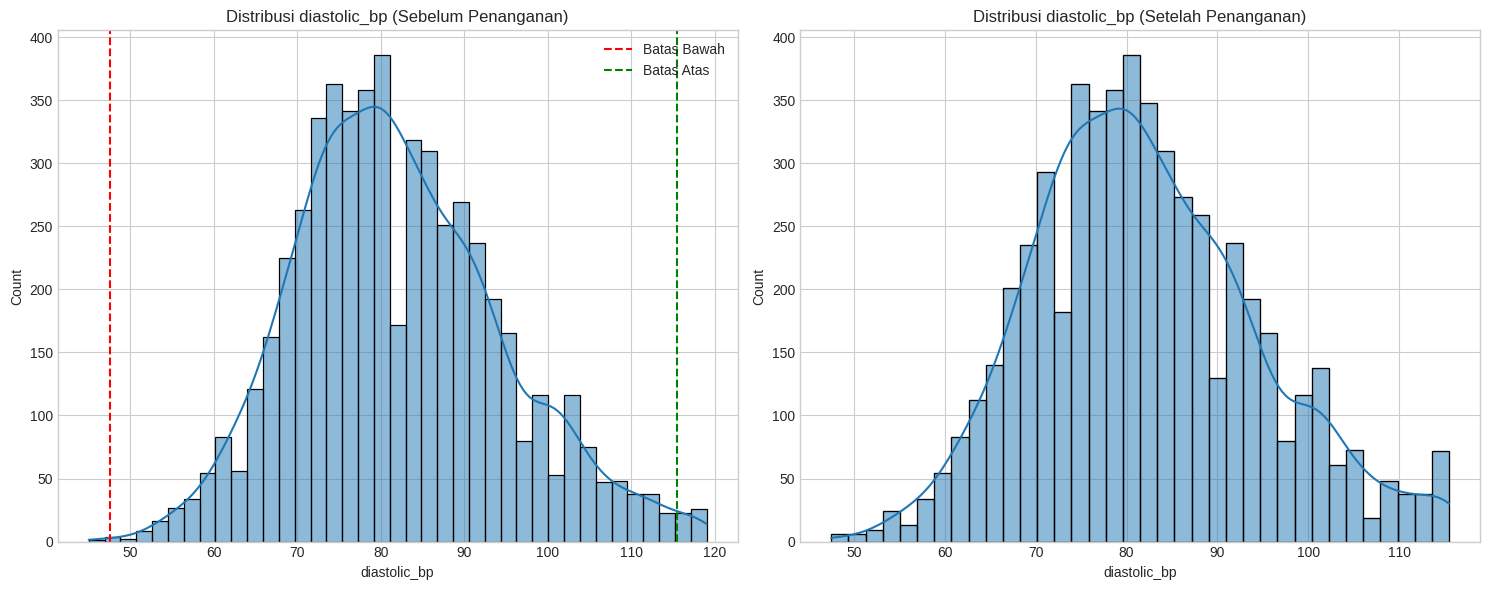

Outliers in glucose: 408


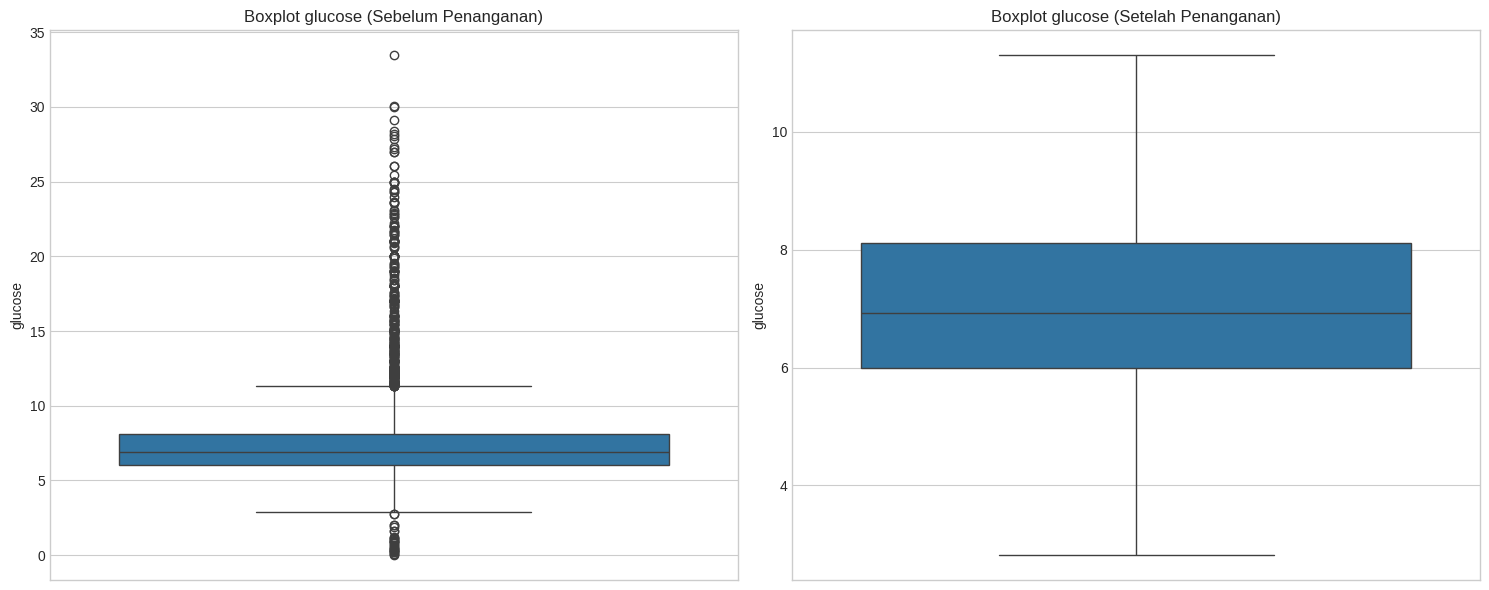

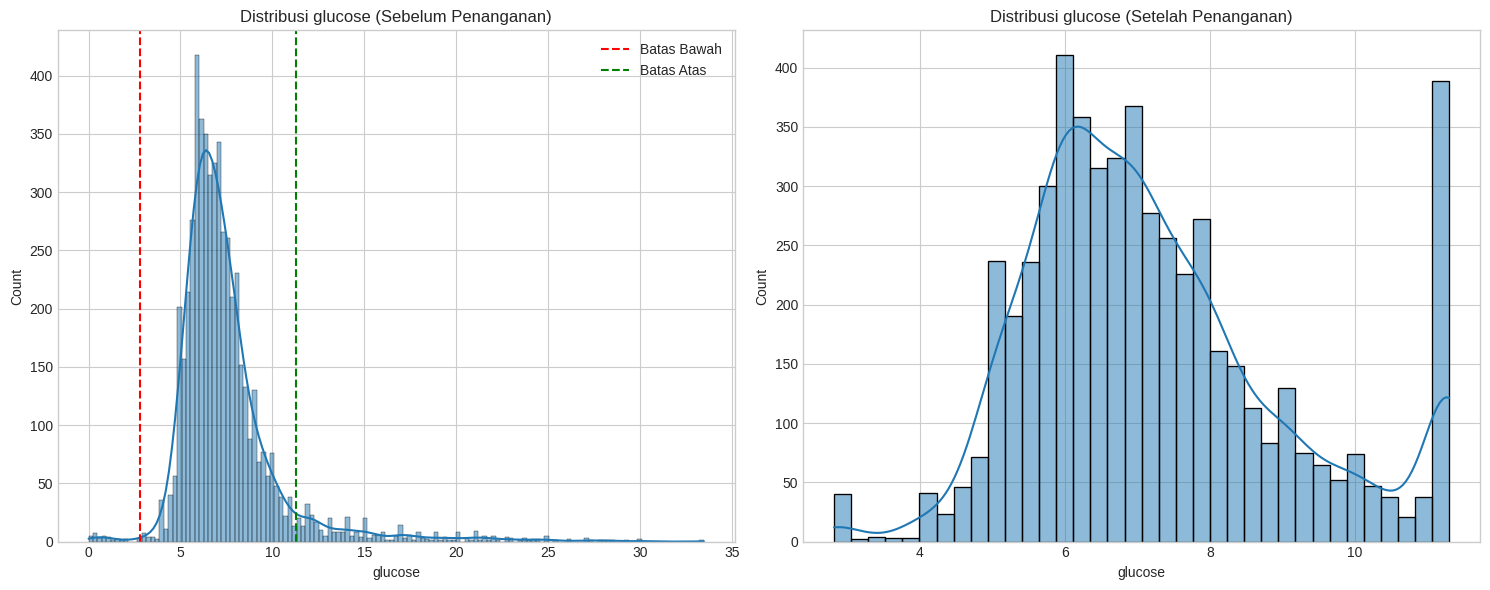

Outliers in height: 198


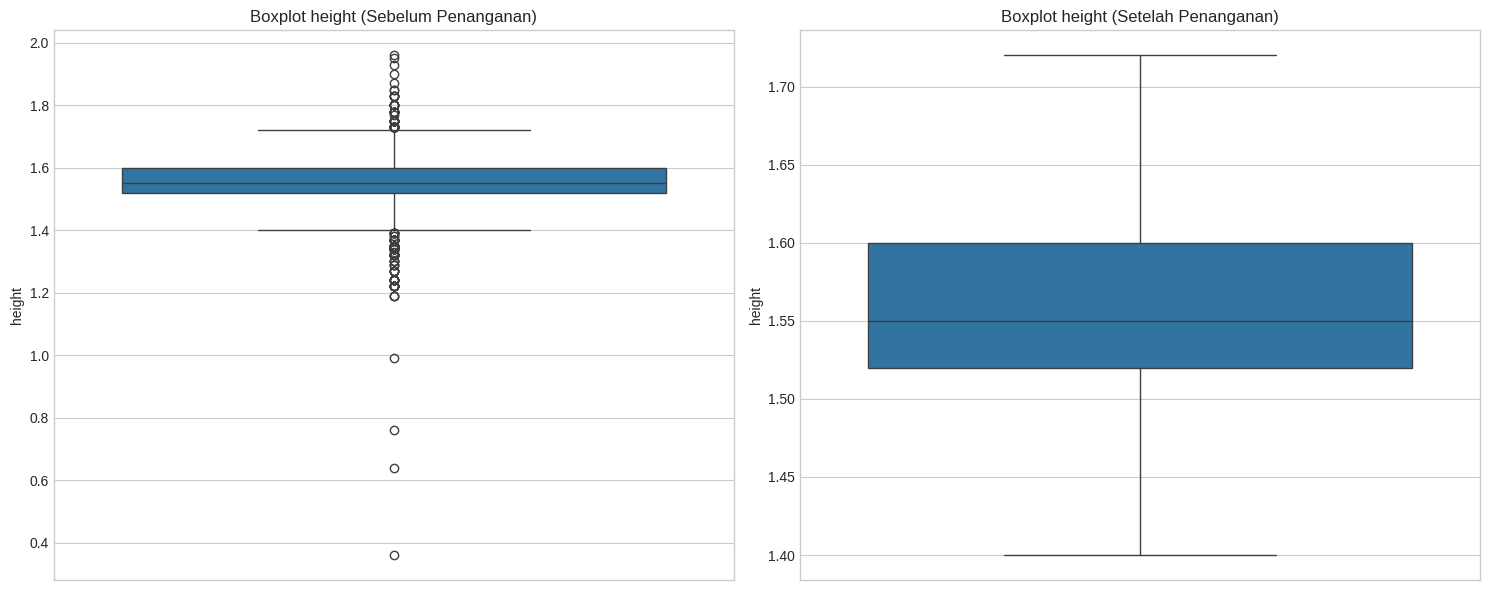

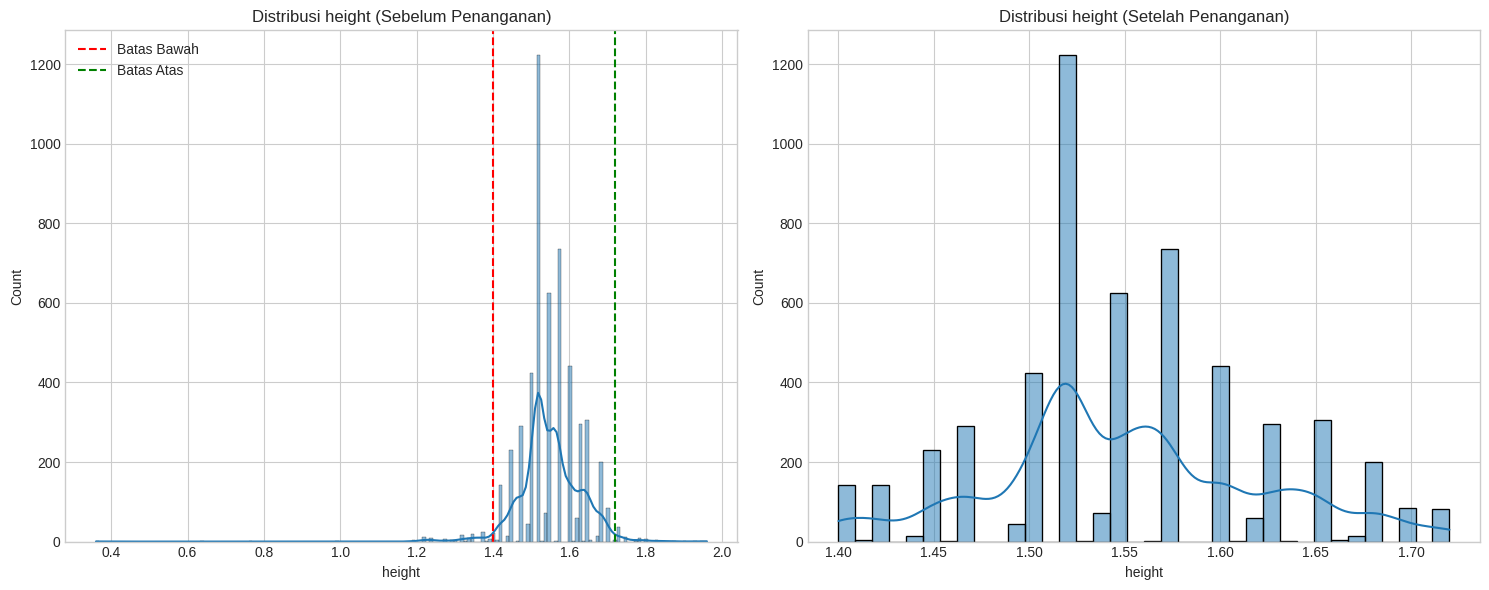

Outliers in weight: 84


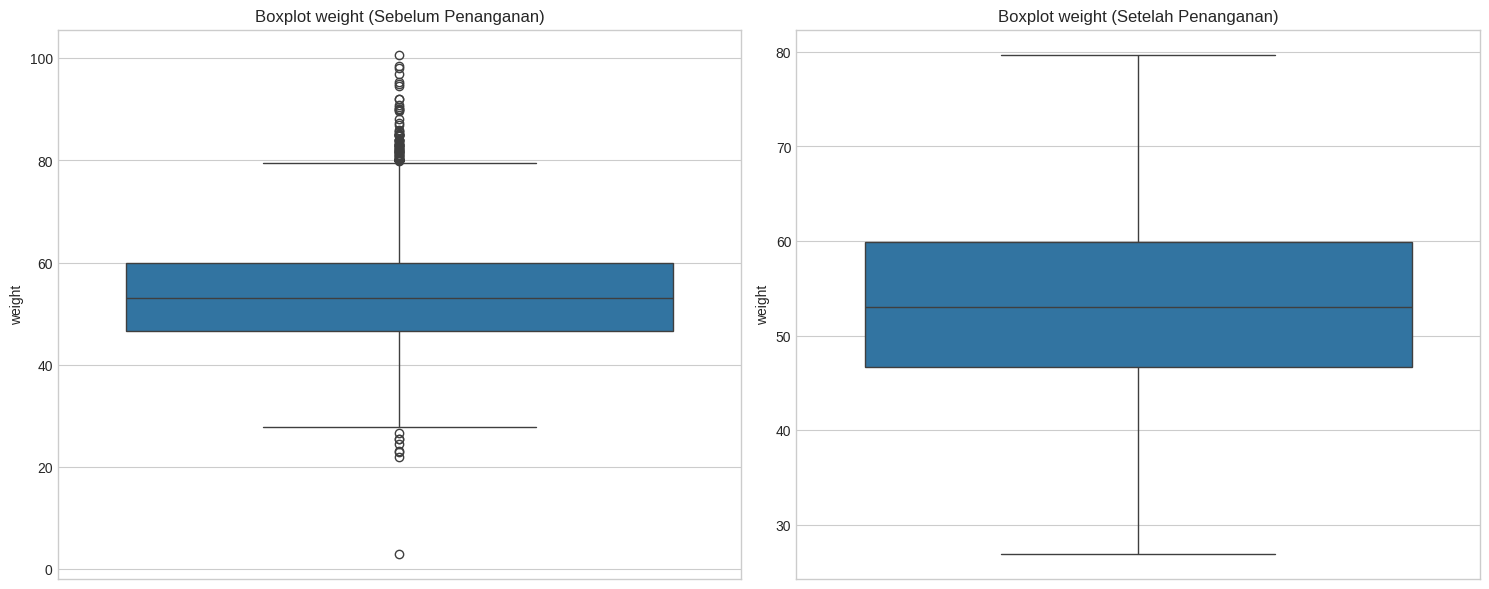

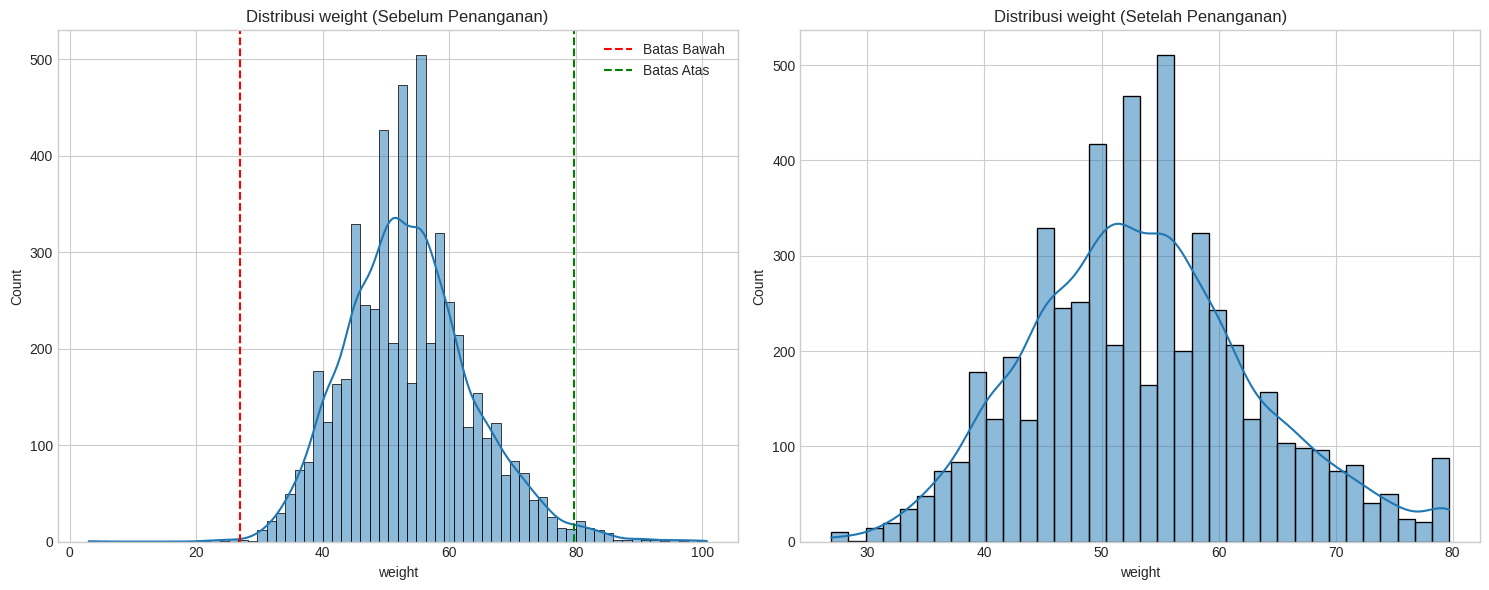

Outliers in bmi: 139


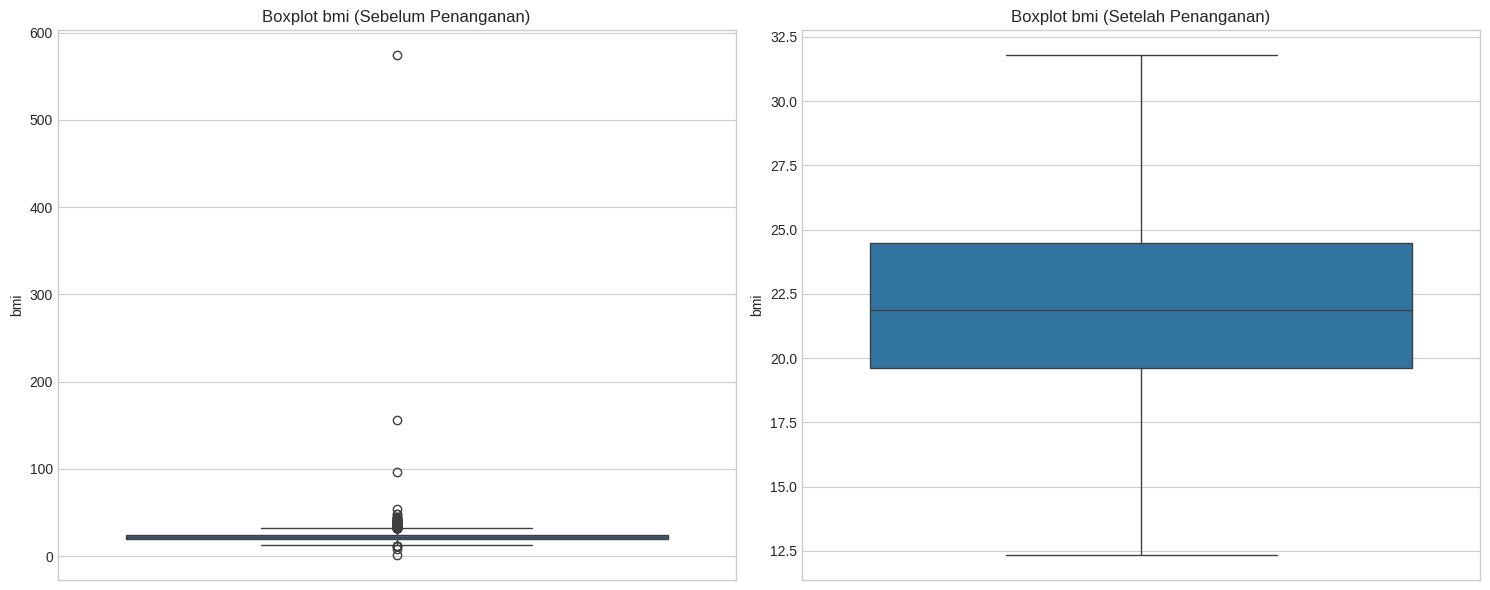

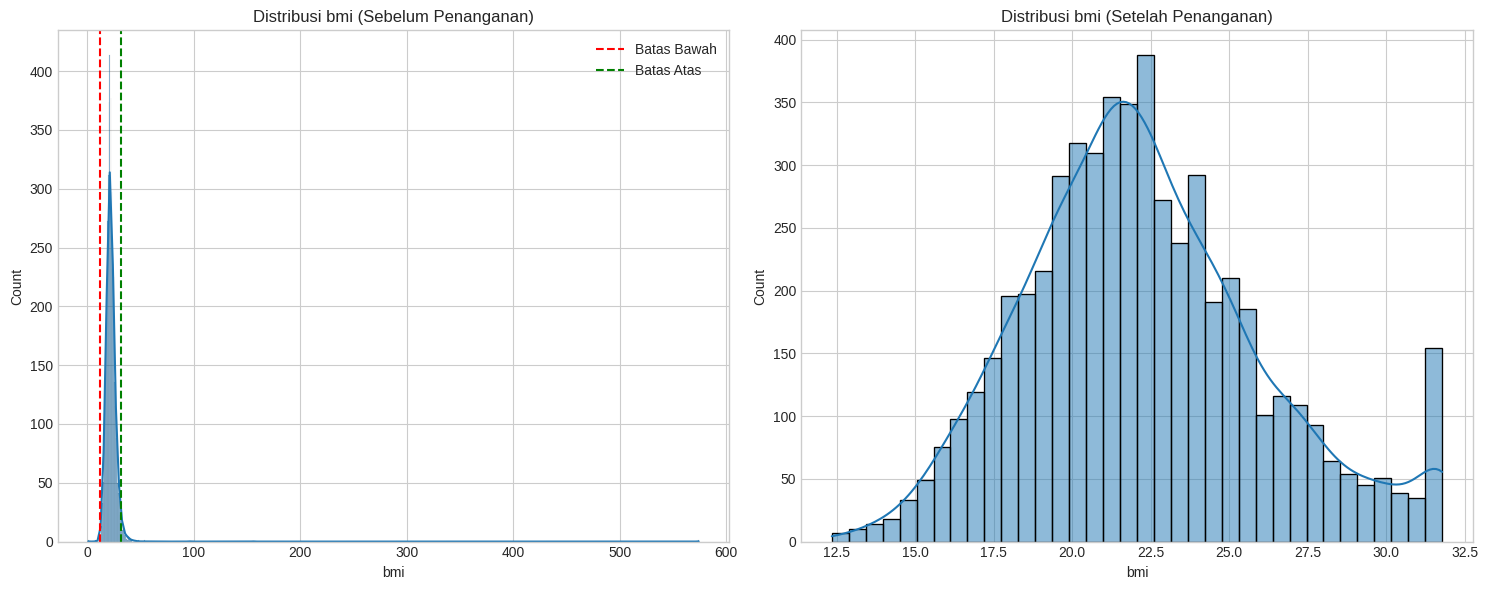

In [ ]:
def visualize_after_outlier_handling(df_no_missing):
    print("=" * 50)
    print("VISUALISASI SETELAH PENANGANAN OUTLIER")
    print("=" * 50)

    # Buat salinan
    df_no_outliers = df_no_missing.copy()

    # Fungsi untuk menangani outlier dengan IQR
    def handle_outliers_iqr(df, column):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
        print(f"Outliers in {column}: {outliers}")

        df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
        df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

        return df, outliers

    # Kolom untuk penanganan outlier
    columns_for_outlier = ['age', 'pulse_rate', 'systolic_bp', 'diastolic_bp',
                           'glucose', 'height', 'weight', 'bmi']

    # Visualisasi outlier sebelum dan sesudah penanganan
    for col in columns_for_outlier:
        # Hitung batas IQR untuk visualisasi
        Q1 = df_no_missing[col].quantile(0.25)
        Q3 = df_no_missing[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Tangani outlier
        df_no_outliers, n_outliers = handle_outliers_iqr(df_no_outliers, col)

        if n_outliers > 0:
            plt.figure(figsize=(15, 6))

            plt.subplot(1, 2, 1)
            sns.boxplot(y=df_no_missing[col])
            plt.title(f'Boxplot {col} (Sebelum Penanganan)')

            plt.subplot(1, 2, 2)
            sns.boxplot(y=df_no_outliers[col])
            plt.title(f'Boxplot {col} (Setelah Penanganan)')

            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(15, 6))

            plt.subplot(1, 2, 1)
            sns.histplot(df_no_missing[col], kde=True)
            plt.axvline(x=lower_bound, color='r', linestyle='--', label='Batas Bawah')
            plt.axvline(x=upper_bound, color='g', linestyle='--', label='Batas Atas')
            plt.title(f'Distribusi {col} (Sebelum Penanganan)')
            plt.legend()

            plt.subplot(1, 2, 2)
            sns.histplot(df_no_outliers[col], kde=True)
            plt.title(f'Distribusi {col} (Setelah Penanganan)')

            plt.tight_layout()
            plt.show()

    return df_no_outliers

df_no_outliers = visualize_after_outlier_handling(df_no_missing)

In [ ]:
def visualize_after_scaling(df_no_outliers):
    print("=" * 50)
    print("VISUALISASI SETELAH SCALING")
    print("=" * 50)

    # Buat salinan dan persiapkan fitur
    df_scaled = df_no_outliers.copy()

    # Persiapan fitur dan target
    features = ['age', 'gender_encoded', 'pulse_rate', 'systolic_bp', 'diastolic_bp',
               'glucose', 'height', 'weight', 'bmi', 'bp_ratio', 'bmi_category_encoded',
               'glucose_family_interaction', 'cv_risk_score',
               'family_diabetes', 'hypertensive', 'family_hypertension',
               'cardiovascular_disease', 'stroke']

    X = df_scaled[features]
    y = df_scaled['diabetic_encoded']

    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

    # Visualisasi distribusi sebelum dan sesudah scaling untuk beberapa fitur
    sample_features = ['age', 'glucose', 'bmi', 'systolic_bp', 'bp_ratio', 'cv_risk_score']

    for feature in sample_features:
        plt.figure(figsize=(15, 6))

        plt.subplot(1, 2, 1)
        sns.histplot(X[feature], kde=True)
        plt.title(f'Distribusi {feature} (Sebelum Scaling)')

        plt.subplot(1, 2, 2)
        sns.histplot(X_scaled_df[feature], kde=True)
        plt.title(f'Distribusi {feature} (Setelah Scaling)')

        plt.tight_layout()
        plt.show()

    # Boxplot perbandingan scale
    plt.figure(figsize=(15, 10))

    plt.subplot(1, 2, 1)
    sns.boxplot(data=X[sample_features])
    plt.title('Boxplot Fitur Sebelum Scaling')
    plt.xticks(rotation=45, ha='right')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=X_scaled_df[sample_features])
    plt.title('Boxplot Fitur Setelah Scaling')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

    return X_scaled_df, y

VISUALISASI SETELAH SCALING


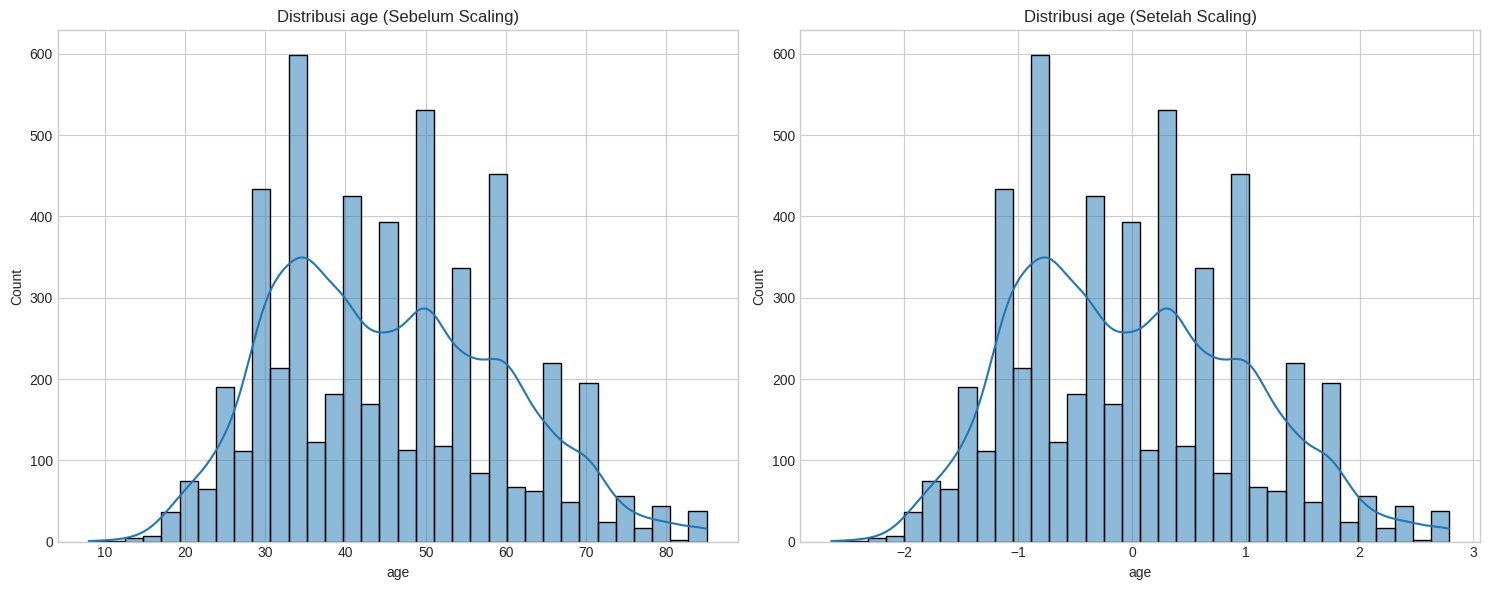

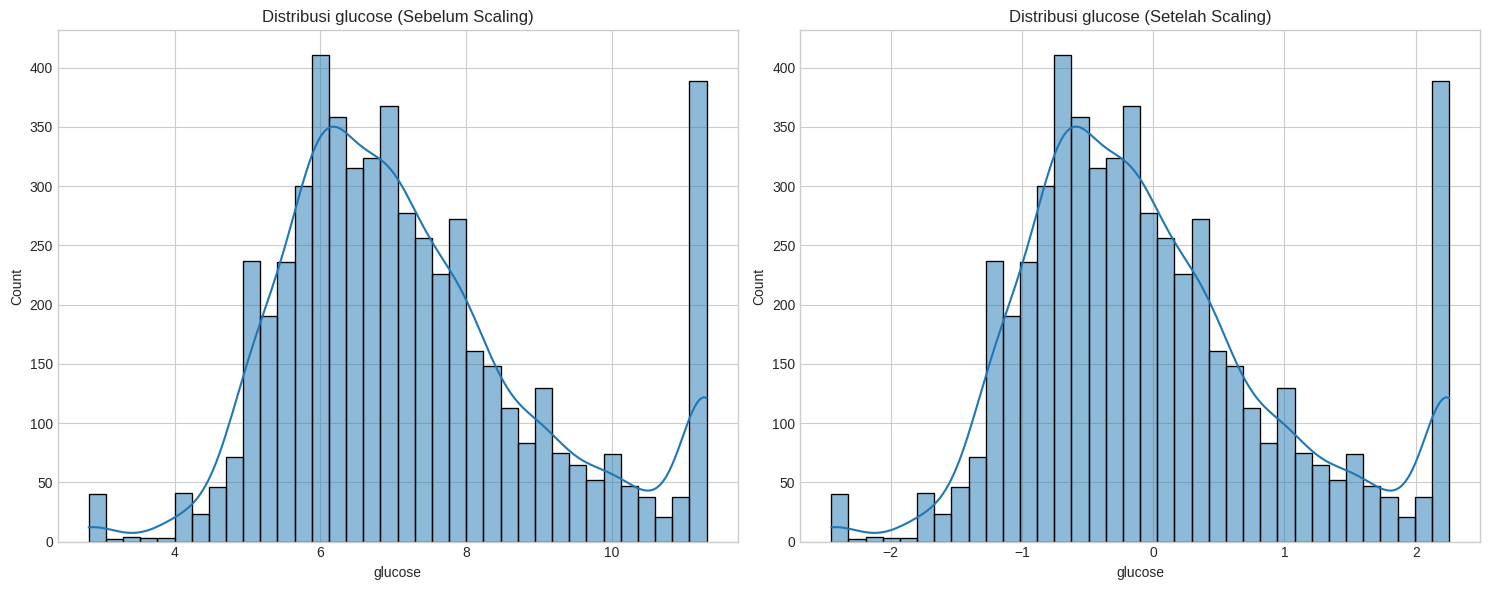

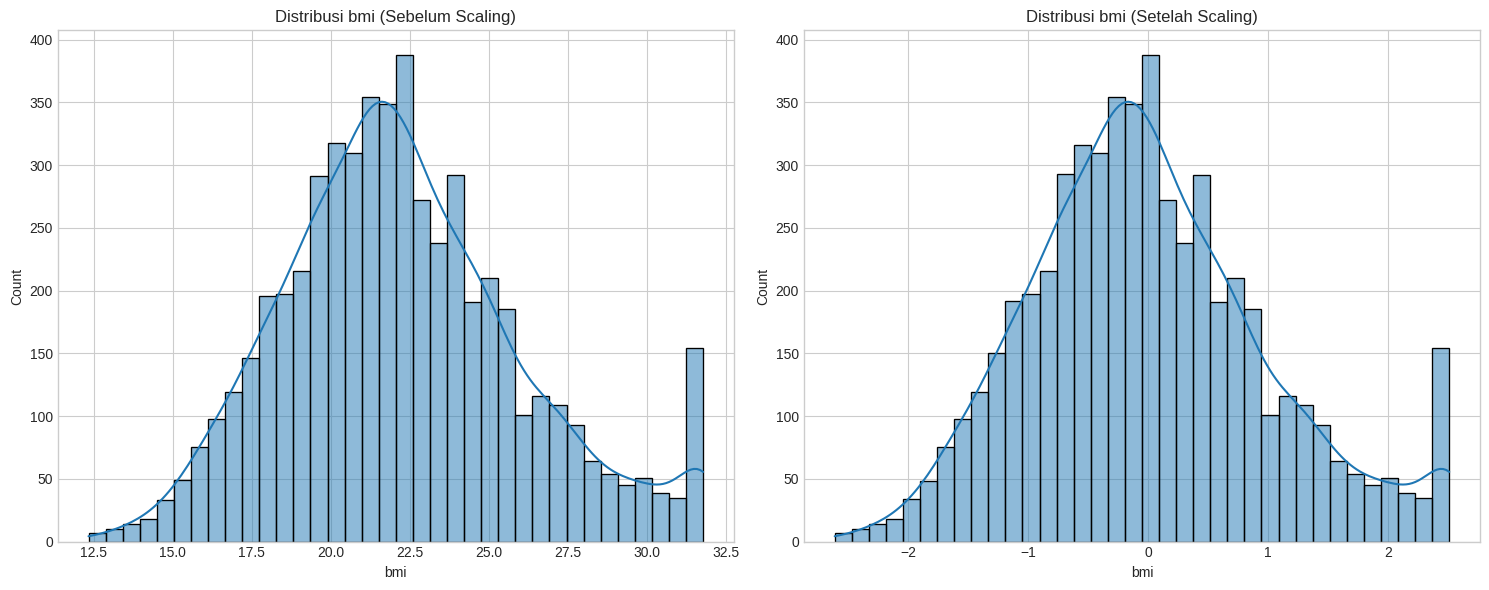

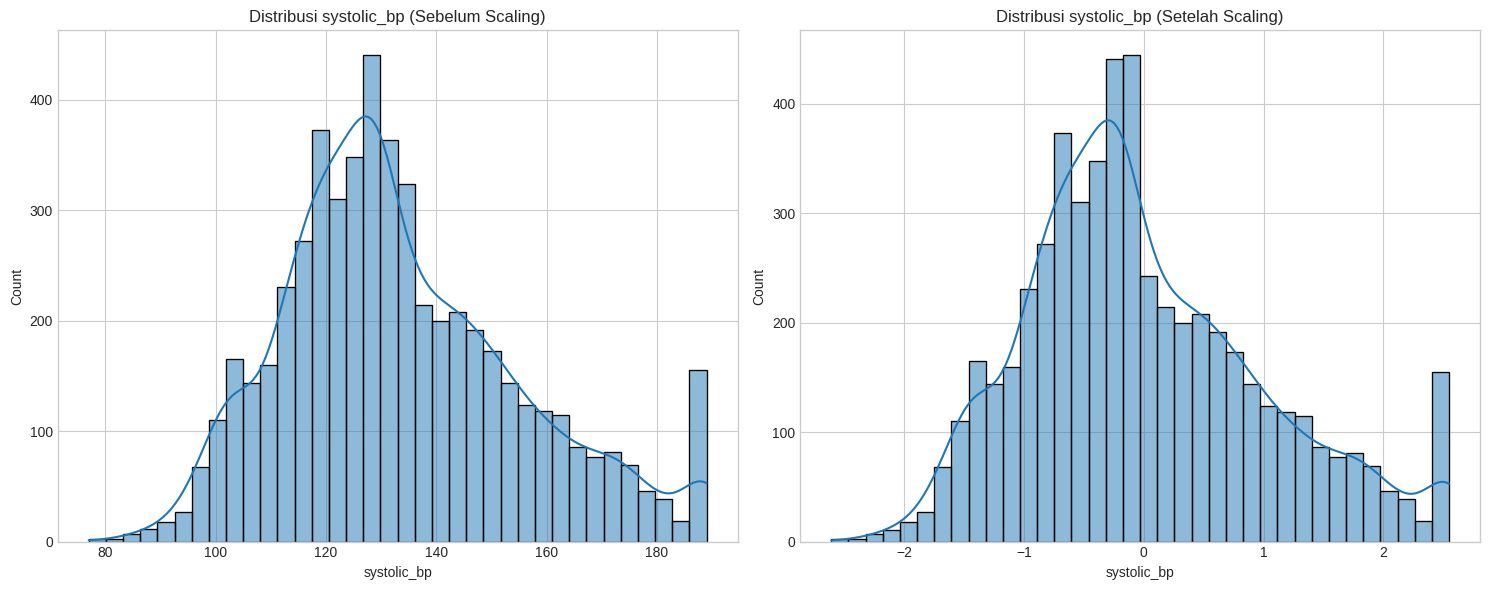

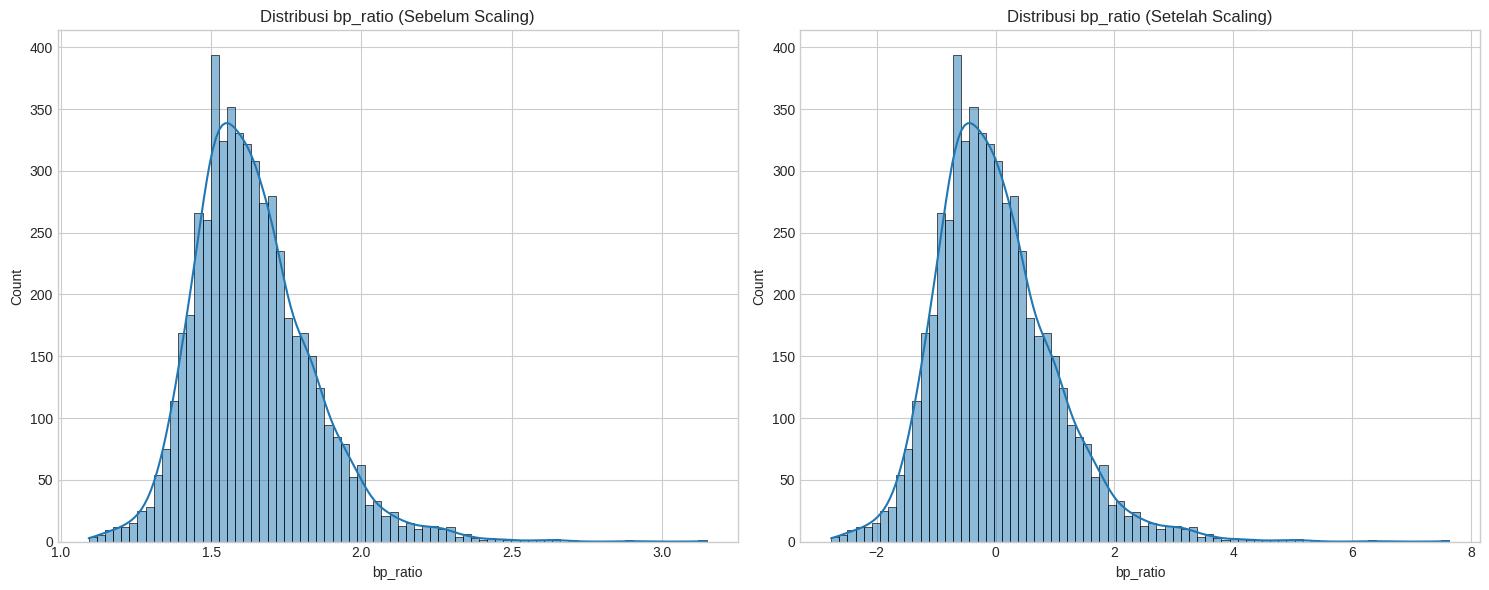

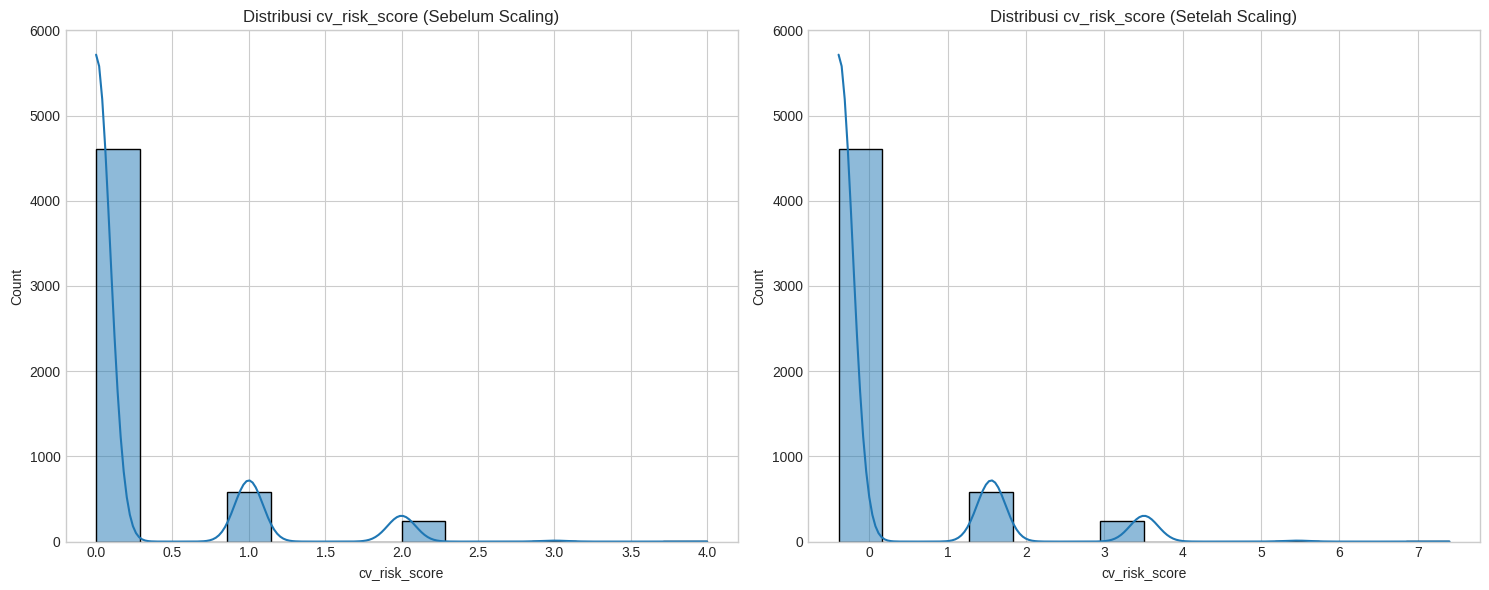

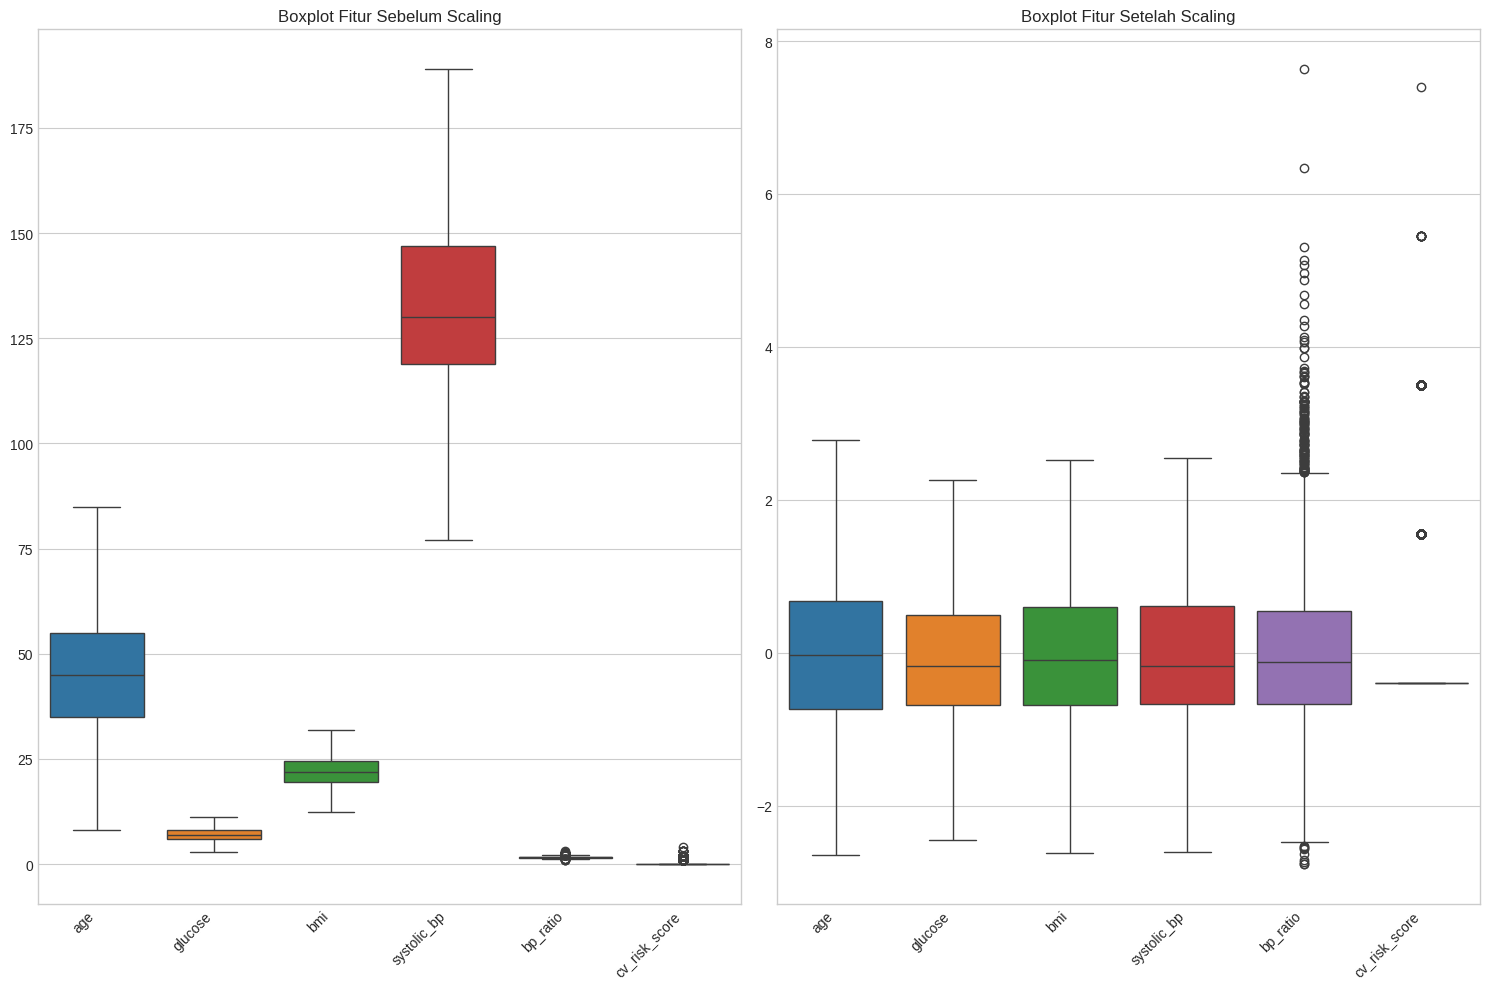

In [ ]:
X_scaled_df, y = visualize_after_scaling(df_no_outliers)

In [ ]:
# Pendekatan: SMOTE pada seluruh dataset
print("\n=== PENDEKATAN: APPLY SMOTE PADA SELURUH DATASET ===")

# Terapkan SMOTE pada seluruh dataset
print("\nMenerapkan SMOTE pada seluruh dataset...")
smote = SMOTE(random_state=42, sampling_strategy=1.0)  # 1:1 ratio
X_resampled, y_resampled = smote.fit_resample(X_scaled_df, y)

# Split dataset yang sudah di-SMOTE
print("\nSplit dataset yang sudah di-SMOTE menjadi train dan test...")
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train.shape}, {pd.Series(y_train).value_counts()}")
print(f"Testing set shape: {X_test.shape}, {pd.Series(y_test).value_counts()}")



=== PENDEKATAN: APPLY SMOTE PADA SELURUH DATASET ===

Menerapkan SMOTE pada seluruh dataset...

Split dataset yang sudah di-SMOTE menjadi train dan test...
Training set shape: (8148, 18), diabetic_encoded
1    4087
0    4061
Name: count, dtype: int64
Testing set shape: (2038, 18), diabetic_encoded
0    1032
1    1006
Name: count, dtype: int64


In [ ]:
# Fungsi untuk evaluasi model dengan metrics yang diminta
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train and evaluate a model."""
    print(f"\nEvaluating {model_name}...")

    # Train the model
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Make predictions
    y_pred = model.predict(X_test)

    # For probability-based metrics
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        has_proba = True
    except:
        y_prob = None
        has_proba = False

    # Calculate metrics
    metrics = {}
    metrics['accuracy'] = accuracy_score(y_test, y_pred)
    metrics['precision'] = precision_score(y_test, y_pred)
    metrics['recall'] = recall_score(y_test, y_pred)
    metrics['f1'] = f1_score(y_test, y_pred)
    metrics['mcc'] = matthews_corrcoef(y_test, y_pred)

    if has_proba:
        metrics['roc_auc'] = roc_auc_score(y_test, y_prob)
        metrics['log_loss'] = log_loss(y_test, y_prob)
        metrics['brier_score'] = brier_score_loss(y_test, y_prob)
        metrics['avg_precision'] = average_precision_score(y_test, y_prob)

    # Print results
    print(f"\n{model_name} Results:")
    print(f"Training time: {train_time:.4f} seconds")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")
    print(f"MCC: {metrics['mcc']:.4f}")

    if has_proba:
        print(f"ROC AUC: {metrics['roc_auc']:.4f}")
        print(f"Log Loss: {metrics['log_loss']:.4f}")
        print(f"Brier Score: {metrics['brier_score']:.4f}")
        print(f"Average Precision: {metrics['avg_precision']:.4f}")

    # Print confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    return model, metrics

In [ ]:
# Function to train default models
def train_default_models(X_train, X_test, y_train, y_test):
    """Train and evaluate default models."""
    print("\n" + "="*50)
    print("TRAINING DEFAULT MODELS")
    print("="*50)

    # Initialize default models
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'Random Forest': RandomForestClassifier(),
        'KNN': KNeighborsClassifier(),
        'SVM': SVC(probability=True),
        'XGBoost': xgb.XGBClassifier()
    }

    # Train and evaluate each model
    results = {}
    for name, model in models.items():
        trained_model, metrics = evaluate_model(model, X_train, X_test, y_train, y_test, f"Default {name}")
        results[name] = (trained_model, metrics)

    return results

In [ ]:
# Function to tune Logistic Regression
def tune_logistic_regression(X_train, y_train):
    """Tune Logistic Regression model."""
    print("\n" + "="*50)
    print("LOGISTIC REGRESSION TUNING")
    print("="*50)

    # Grid search untuk Logistic Regression
    lr_grid_search_results = []

    # liblinear solver supports l1 and l2
    param_grid_liblinear = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'],
        'max_iter': [1000]
    }

    grid_liblinear = GridSearchCV(
        LogisticRegression(),
        param_grid_liblinear,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    print("\nTuning Logistic Regression (liblinear)...")
    start_time = time.time()
    grid_liblinear.fit(X_train, y_train)
    time_liblinear = time.time() - start_time
    lr_grid_search_results.append((grid_liblinear.best_score_, grid_liblinear.best_params_, grid_liblinear.best_estimator_, time_liblinear))

    # saga solver supports l1, l2, elasticnet
    param_grid_saga = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['saga'],
        'l1_ratio': [0.2, 0.5, 0.8],  # only for elasticnet
        'max_iter': [1000]
    }

    grid_saga = GridSearchCV(
        LogisticRegression(),
        param_grid_saga,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    print("\nTuning Logistic Regression (saga)...")
    start_time = time.time()
    grid_saga.fit(X_train, y_train)
    time_saga = time.time() - start_time
    lr_grid_search_results.append((grid_saga.best_score_, grid_saga.best_params_, grid_saga.best_estimator_, time_saga))

    # None penalty with newton-cg, lbfgs, sag
    param_grid_none = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': [None],
        'solver': ['newton-cg', 'lbfgs', 'sag'],
        'max_iter': [1000]
    }

    grid_none = GridSearchCV(
        LogisticRegression(),
        param_grid_none,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    print("\nTuning Logistic Regression (none penalty)...")
    start_time = time.time()
    grid_none.fit(X_train, y_train)
    time_none = time.time() - start_time
    lr_grid_search_results.append((grid_none.best_score_, grid_none.best_params_, grid_none.best_estimator_, time_none))

    # Get best result
    lr_best_result = max(lr_grid_search_results, key=lambda x: x[0])
    lr_best_score = lr_best_result[0]
    lr_best_params = lr_best_result[1]
    lr_tuned_model = lr_best_result[2]
    lr_tuning_time = lr_best_result[3]

    print(f"\nBest Logistic Regression parameters: {lr_best_params}")
    print(f"Best CV score: {lr_best_score:.4f}")
    print(f"Tuning time: {lr_tuning_time:.2f} seconds")

    return lr_tuned_model

In [ ]:
# Function to tune Random Forest
def tune_random_forest(X_train, y_train):
    """Tune Random Forest model."""
    print("\n" + "="*50)
    print("RANDOM FOREST TUNING")
    print("="*50)

    param_grid_rf = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }

    grid_rf = GridSearchCV(
        RandomForestClassifier(),
        param_grid_rf,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print("\nTuning Random Forest...")
    start_time = time.time()
    grid_rf.fit(X_train, y_train)
    rf_tuning_time = time.time() - start_time

    rf_best_params = grid_rf.best_params_
    rf_best_score = grid_rf.best_score_
    rf_tuned_model = grid_rf.best_estimator_

    print(f"\nBest Random Forest parameters: {rf_best_params}")
    print(f"Best CV score: {rf_best_score:.4f}")
    print(f"Tuning time: {rf_tuning_time:.2f} seconds")

    return rf_tuned_model

In [ ]:
# Function to tune KNN
def tune_knn(X_train, y_train):
    """Tune KNN model."""
    print("\n" + "="*50)
    print("KNN TUNING")
    print("="*50)

    param_grid_knn = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'p': [1, 2],  # Manhattan or Euclidean distance
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    }

    grid_knn = GridSearchCV(
        KNeighborsClassifier(),
        param_grid_knn,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print("\nTuning KNN...")
    start_time = time.time()
    grid_knn.fit(X_train, y_train)
    knn_tuning_time = time.time() - start_time

    knn_best_params = grid_knn.best_params_
    knn_best_score = grid_knn.best_score_
    knn_tuned_model = grid_knn.best_estimator_

    print(f"\nBest KNN parameters: {knn_best_params}")
    print(f"Best CV score: {knn_best_score:.4f}")
    print(f"Tuning time: {knn_tuning_time:.2f} seconds")

    return knn_tuned_model


# Function to tune SVM
def tune_svm(X_train, y_train):
    """Tune SVM model."""
    print("\n" + "="*50)
    print("SVM TUNING")
    print("="*50)

    param_grid_svm = [
        {   # Linear kernel
            'kernel': ['linear'],
            'C': [1, 10],
        },
        {   # RBF kernel
            'kernel': ['rbf'],
            'C': [1, 10],
            'gamma': ['scale', 0.1],
        },
        {   # Polynomial kernel
            'kernel': ['poly'],
            'C': [1],
            'gamma': ['scale'],
            'degree': [2],
        }
    ]

    grid_svm = GridSearchCV(
        SVC(probability=True),
        param_grid_svm,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print("\nTuning SVM...")
    start_time = time.time()
    grid_svm.fit(X_train, y_train)
    svm_tuning_time = time.time() - start_time

    svm_best_params = grid_svm.best_params_
    svm_best_score = grid_svm.best_score_
    svm_tuned_model = grid_svm.best_estimator_

    print(f"\nBest SVM parameters: {svm_best_params}")
    print(f"Best CV score: {svm_best_score:.4f}")
    print(f"Tuning time: {svm_tuning_time:.2f} seconds")

    return svm_tuned_model


# Function to tune XGBoost
def tune_xgboost(X_train, y_train):
    """Tune XGBoost model."""
    print("\n" + "="*50)
    print("XGBOOST TUNING")
    print("="*50)

    param_grid_xgb = {
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'n_estimators': [100, 200],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }

    grid_xgb = GridSearchCV(
        xgb.XGBClassifier(),
        param_grid_xgb,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print("\nTuning XGBoost...")
    start_time = time.time()
    grid_xgb.fit(X_train, y_train)
    xgb_tuning_time = time.time() - start_time

    xgb_best_params = grid_xgb.best_params_
    xgb_best_score = grid_xgb.best_score_
    xgb_tuned_model = grid_xgb.best_estimator_

    print(f"\nBest XGBoost parameters: {xgb_best_params}")
    print(f"Best CV score: {xgb_best_score:.4f}")
    print(f"Tuning time: {xgb_tuning_time:.2f} seconds")

    return xgb_tuned_model


In [ ]:
# Function to create and evaluate ensemble models
def create_ensembles(tuned_models, X_train, X_test, y_train, y_test):
   """Create and evaluate ensemble models."""
   print("\n" + "="*50)
   print("CREATING ENSEMBLE MODELS")
   print("="*50)

   # Extract tuned models
   lr_model = tuned_models['Logistic Regression'][0]
   rf_model = tuned_models['Random Forest'][0]
   knn_model = tuned_models['KNN'][0]
   svm_model = tuned_models['SVM'][0]
   xgb_model = tuned_models['XGBoost'][0]

   # Create voting classifiers
   # Hard voting
   hard_voting = VotingClassifier(
       estimators=[
           ('lr', lr_model),
           ('rf', rf_model),
           ('knn', knn_model),
           ('svm', svm_model),
           ('xgb', xgb_model)
       ],
       voting='hard'
   )

   # Soft voting
   soft_voting = VotingClassifier(
       estimators=[
           ('lr', lr_model),
           ('rf', rf_model),
           ('knn', knn_model),
           ('svm', svm_model),
           ('xgb', xgb_model)
       ],
       voting='soft'
   )

   # Evaluate ensembles
   hard_voting_model, hard_voting_metrics = evaluate_model(
       hard_voting, X_train, X_test, y_train, y_test, "Hard Voting Ensemble"
   )

   soft_voting_model, soft_voting_metrics = evaluate_model(
       soft_voting, X_train, X_test, y_train, y_test, "Soft Voting Ensemble"
   )

   # Return ensemble models and metrics
   ensemble_results = {
       'Hard Voting': (hard_voting_model, hard_voting_metrics),
       'Soft Voting': (soft_voting_model, soft_voting_metrics)
   }

   return ensemble_results

In [ ]:
# Function to visualize model comparison for a specific metric
def plot_metric_comparison(default_models, tuned_models, ensemble_models, metric_name, metric_title):
   """Plot model comparison for a specific metric."""

   # Combine results from all models
   all_results = {}

   for name, (model, metrics) in default_models.items():
       if metric_name in metrics:
           all_results[f"Default {name}"] = metrics[metric_name]

   for name, (model, metrics) in tuned_models.items():
       if metric_name in metrics:
           all_results[f"Tuned {name}"] = metrics[metric_name]

   for name, (model, metrics) in ensemble_models.items():
       if metric_name in metrics:
           all_results[f"{name} Ensemble"] = metrics[metric_name]

   # Convert to DataFrame for easier plotting
   results_df = pd.DataFrame(list(all_results.items()), columns=['Model', metric_name])

   # Sort by metric value (ascending for loss metrics, descending for others)
   if metric_name in ['log_loss', 'brier_score']:
       results_df = results_df.sort_values(by=metric_name, ascending=True)
   else:
       results_df = results_df.sort_values(by=metric_name, ascending=False)

   # Create color mapping for model types
   colors = []
   for model in results_df['Model']:
       if 'Default' in model:
           colors.append('blue')
       elif 'Tuned' in model:
           colors.append('green')
       else:
           colors.append('red')

   # Create plot
   plt.figure(figsize=(12, 6))
   ax = sns.barplot(x='Model', y=metric_name, data=results_df, palette=colors)

   plt.title(f'Model Comparison by {metric_title}', fontsize=16)
   plt.ylabel(metric_title, fontsize=14)
   plt.xlabel('', fontsize=14)
   plt.xticks(rotation=45, ha='right')
   plt.grid(axis='y', linestyle='--', alpha=0.7)

   # Add value labels on the bars
   for i, v in enumerate(results_df[metric_name]):
       ax.text(i, v + (0.01 if metric_name not in ['log_loss', 'brier_score'] else -0.01),
               f'{v:.4f}', ha='center', va='bottom' if metric_name not in ['log_loss', 'brier_score'] else 'top',
               fontsize=9, rotation=0)

   plt.tight_layout()
   plt.savefig(f'{metric_name}_comparison.png')
   plt.show()

   return results_df

In [ ]:
# Function to plot all metrics comparison in one figure
def plot_all_metrics(default_models, tuned_models, ensemble_models):
   """Plot all metrics comparison in one figure."""

   # Metrics to plot
   metrics = {
       'f1': 'F1 Score',
       'roc_auc': 'ROC AUC',
       'log_loss': 'Log Loss',
       'brier_score': 'Brier Score',
       'mcc': 'Matthews Correlation Coefficient',
       'avg_precision': 'Average Precision'
   }

   # Set up the figure
   fig, axes = plt.subplots(3, 2, figsize=(20, 15))
   axes = axes.flatten()

   # Plot each metric
   for i, (metric_name, metric_title) in enumerate(metrics.items()):
       # Combine results from all models
       all_results = {}

       for name, (model, model_metrics) in default_models.items():
           if metric_name in model_metrics:
               all_results[f"Default {name}"] = model_metrics[metric_name]

       for name, (model, model_metrics) in tuned_models.items():
           if metric_name in model_metrics:
               all_results[f"Tuned {name}"] = model_metrics[metric_name]

       for name, (model, model_metrics) in ensemble_models.items():
           if metric_name in model_metrics:
               all_results[f"{name} Ensemble"] = model_metrics[metric_name]

       # Convert to DataFrame for easier plotting
       results_df = pd.DataFrame(list(all_results.items()), columns=['Model', metric_name])

       # Sort by metric value (ascending for loss metrics, descending for others)
       if metric_name in ['log_loss', 'brier_score']:
           results_df = results_df.sort_values(by=metric_name, ascending=True)
       else:
           results_df = results_df.sort_values(by=metric_name, ascending=False)

       # Create color mapping for model types
       colors = []
       for model in results_df['Model']:
           if 'Default' in model:
               colors.append('blue')
           elif 'Tuned' in model:
               colors.append('green')
           else:
               colors.append('red')

       # Plot on the corresponding subplot
       ax = axes[i]
       sns.barplot(x='Model', y=metric_name, data=results_df, palette=colors, ax=ax)

       ax.set_title(metric_title, fontsize=14)
       ax.set_ylabel(metric_title, fontsize=12)
       ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
       ax.grid(axis='y', linestyle='--', alpha=0.7)

       # Add value labels on the bars
       for j, v in enumerate(results_df[metric_name]):
           ax.text(j, v + (0.01 if metric_name not in ['log_loss', 'brier_score'] else -0.01),
                   f'{v:.4f}', ha='center', va='bottom' if metric_name not in ['log_loss', 'brier_score'] else 'top',
                   fontsize=8, rotation=0)

   plt.tight_layout()
   plt.savefig('all_metrics_comparison.png')
   plt.show()

In [ ]:
# Function to find top 3 models
def find_top_3_models(default_models, tuned_models, ensemble_models):
   """Find the top 3 models based on multiple metrics."""
   print("\n" + "="*50)
   print("TOP 3 MODELS")
   print("="*50)

   # Metrics to consider
   positive_metrics = ['f1', 'roc_auc', 'mcc', 'avg_precision']
   negative_metrics = ['log_loss', 'brier_score']

   # Combine all model results
   all_models = {}

   for name, (model, metrics) in default_models.items():
       all_models[f"Default {name}"] = metrics

   for name, (model, metrics) in tuned_models.items():
       all_models[f"Tuned {name}"] = metrics

   for name, (model, metrics) in ensemble_models.items():
       all_models[f"{name} Ensemble"] = metrics

   # Create DataFrame for all metrics
   metrics_df = pd.DataFrame()

   # Add positive metrics
   for metric in positive_metrics:
       metric_values = {}
       for model_name, model_metrics in all_models.items():
           if metric in model_metrics:
               metric_values[model_name] = model_metrics[metric]

       if metric_values:
           metrics_df[metric] = pd.Series(metric_values)

   # Add negative metrics
   for metric in negative_metrics:
       metric_values = {}
       for model_name, model_metrics in all_models.items():
           if metric in model_metrics:
               metric_values[model_name] = model_metrics[metric]

       if metric_values:
           metrics_df[metric] = pd.Series(metric_values)

   # Rank models by metrics
   rank_df = pd.DataFrame()

   # Rank for positive metrics (higher is better)
   for metric in positive_metrics:
       if metric in metrics_df.columns:
           rank_df[f'{metric}_rank'] = metrics_df[metric].rank(ascending=False)

   # Rank for negative metrics (lower is better)
   for metric in negative_metrics:
       if metric in metrics_df.columns:
           rank_df[f'{metric}_rank'] = metrics_df[metric].rank(ascending=True)

   # Calculate average rank
   rank_df['avg_rank'] = rank_df.mean(axis=1)

   # Sort by average rank and get top 3
   top_3_models = rank_df.sort_values('avg_rank').head(3)

   # Display top 3 models with their metrics
   print("Top 3 Models Based on Multiple Metrics:")
   for i, (model_name, _) in enumerate(top_3_models.iterrows(), 1):
       print(f"{i}. {model_name}")
       for metric in positive_metrics + negative_metrics:
           if metric in metrics_df.columns and model_name in metrics_df.index:
               print(f"   {metric}: {metrics_df.loc[model_name, metric]:.4f}")
       print()

   # Plot radar chart for top 3 models
   plt.figure(figsize=(10, 8))

   # Prepare data for radar chart
   top_model_names = top_3_models.index.tolist()

   # Normalize metrics for radar chart (0-1 scale)
   radar_df = metrics_df.copy()

   # For positive metrics: normalize to 0-1 where 1 is best
   for metric in positive_metrics:
       if metric in radar_df.columns:
           min_val = radar_df[metric].min()
           max_val = radar_df[metric].max()
           if max_val > min_val:
               radar_df[metric] = (radar_df[metric] - min_val) / (max_val - min_val)
           else:
               radar_df[metric] = 1.0  # All values are equal

   # For negative metrics: normalize to 0-1 where 1 is best (invert)
   for metric in negative_metrics:
       if metric in radar_df.columns:
           min_val = radar_df[metric].min()
           max_val = radar_df[metric].max()
           if max_val > min_val:
               radar_df[metric] = 1 - (radar_df[metric] - min_val) / (max_val - min_val)
           else:
               radar_df[metric] = 1.0  # All values are equal

   # Set up radar chart
   categories = [m for m in positive_metrics if m in radar_df.columns] + [m for m in negative_metrics if m in radar_df.columns]
   N = len(categories)
   angles = [n / float(N) * 2 * np.pi for n in range(N)]
   angles += angles[:1]  # Close the loop

   # Set up the figure
   fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

   # Add lines for each model
   for i, model in enumerate(top_model_names):
       if model in radar_df.index:
           values = [radar_df.loc[model, cat] for cat in categories]
           values += values[:1]  # Close the loop

           ax.plot(angles, values, linewidth=2, linestyle='solid', label=model)
           ax.fill(angles, values, alpha=0.1)

   # Add category labels
   plt.xticks(angles[:-1], categories, fontsize=12)

   # Add legend
   plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
   plt.title('Top 3 Models Comparison', size=20)

   plt.tight_layout()
   plt.savefig('top_3_models_radar.png')
   plt.show()

   # Detailed bar chart for top 3 models
   # Create a figure with a subplot for each metric
   fig, axes = plt.subplots(3, 2, figsize=(18, 15))
   axes = axes.flatten()

   # For each metric, create a bar chart with the top 3 models
   metric_titles = {
       'f1': 'F1 Score',
       'roc_auc': 'ROC AUC',
       'log_loss': 'Log Loss (lower is better)',
       'brier_score': 'Brier Score (lower is better)',
       'mcc': 'Matthews Correlation Coefficient',
       'avg_precision': 'Average Precision'
   }

   # Plot each metric
   for i, (metric, title) in enumerate(metric_titles.items()):
       if i < len(axes) and metric in metrics_df.columns:
           ax = axes[i]

           # Get data for top 3 models
           model_data = {model: metrics_df.loc[model, metric] if model in metrics_df.index else np.nan
                        for model in top_model_names}

           # Sort models for this metric
           if metric in negative_metrics:
               sorted_models = sorted(model_data.items(), key=lambda x: x[1])
           else:
               sorted_models = sorted(model_data.items(), key=lambda x: x[1], reverse=True)

           # Plot
           x = [model for model, _ in sorted_models]
           y = [value for _, value in sorted_models]

           bars = ax.bar(x, y, color=['blue', 'green', 'red'])

           # Add value labels
           for bar in bars:
               height = bar.get_height()
               ax.text(bar.get_x() + bar.get_width()/2., height + (0.01 if metric not in negative_metrics else -0.01),
                       f'{height:.4f}', ha='center', va='bottom' if metric not in negative_metrics else 'top')

           ax.set_title(title)
           ax.set_xticklabels(x, rotation=45, ha='right')
           ax.grid(axis='y', linestyle='--', alpha=0.7)

   plt.tight_layout()
   plt.savefig('top_3_detailed_comparison.png')
   plt.show()

   return top_3_models.index.tolist()

In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name, ax=None):
   """Plot confusion matrix for a model."""
   cm = confusion_matrix(y_true, y_pred)

   if ax is None:
       plt.figure(figsize=(8, 6))
       ax = plt.gca()

   sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
   ax.set_xlabel('Predicted labels')
   ax.set_ylabel('True labels')
   ax.set_title(f'Confusion Matrix - {model_name}')
   ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])
   ax.set_yticklabels(['Non-Diabetic', 'Diabetic'])

   return ax

def visualize_confusion_matrices(default_models, tuned_models, ensemble_models):
   """Visualize confusion matrices for all models."""
   print("\n" + "="*50)
   print("CONFUSION MATRIX VISUALIZATIONS")
   print("="*50)

   # Count total number of models
   n_models = len(default_models) + len(tuned_models) + len(ensemble_models)

   # Calculate grid dimensions
   rows = (n_models + 2) // 3  # Round up to nearest integer

   # Create figure
   fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 5))
   axes = axes.flatten() if rows > 1 else [axes] if n_models <= 3 else axes.flatten()

   # Plot confusion matrices for default models
   i = 0
   for name, (model, _) in default_models.items():
       # Make predictions
       y_pred = model.predict(X_test)

       # Plot confusion matrix
       plot_confusion_matrix(y_test, y_pred, f"Default {name}", ax=axes[i])
       i += 1

   # Plot confusion matrices for tuned models
   for name, (model, _) in tuned_models.items():
       # Make predictions
       y_pred = model.predict(X_test)

       # Plot confusion matrix
       plot_confusion_matrix(y_test, y_pred, f"Tuned {name}", ax=axes[i])
       i += 1

   # Plot confusion matrices for ensemble models
   for name, (model, _) in ensemble_models.items():
       # Make predictions
       y_pred = model.predict(X_test)

       # Plot confusion matrix
       plot_confusion_matrix(y_test, y_pred, f"{name} Ensemble", ax=axes[i])
       i += 1

   # Hide any unused subplots
   for j in range(i, len(axes)):
       axes[j].axis('off')

   plt.tight_layout()
   plt.savefig('all_confusion_matrices.png')
   plt.show()

def visualize_model_performance(model_type, default_models, tuned_models, ensemble_models):
   """Visualize detailed performance metrics for a specific model type."""
   print(f"\nVisualizing performance metrics for {model_type}...")

   # Get models based on type
   if model_type in default_models:
       default_model, default_metrics = default_models[model_type]
       tuned_model, tuned_metrics = tuned_models[model_type] if model_type in tuned_models else (None, None)

       # Set up figure
       fig = plt.figure(figsize=(20, 15))

       # Define grid - 3x2 for metrics and 1x2 for confusion matrices
       gs = fig.add_gridspec(4, 2)

       # Plot metrics
       metrics_to_plot = [
           ('f1', 'F1 Score'),
           ('roc_auc', 'ROC AUC'),
           ('log_loss', 'Log Loss'),
           ('brier_score', 'Brier Score'),
           ('mcc', 'Matthews Correlation Coefficient'),
           ('avg_precision', 'Average Precision')
       ]

       # Create dataframe for metrics
       metrics_data = []
       for metric_name, _ in metrics_to_plot:
           if metric_name in default_metrics:
               metrics_data.append({
                   'Metric': metric_name,
                   'Default': default_metrics[metric_name],
                   'Tuned': tuned_metrics[metric_name] if tuned_metrics else None
               })

       metrics_df = pd.DataFrame(metrics_data)

       # Plot bar chart for each metric
       for i, (metric_name, metric_title) in enumerate(metrics_to_plot):
           row = i // 2
           col = i % 2

           ax = fig.add_subplot(gs[row, col])

           # Get data
           if metric_name in metrics_df['Metric'].values:
               metric_row = metrics_df[metrics_df['Metric'] == metric_name].iloc[0]

               # Create bar chart
               model_types = ['Default', 'Tuned'] if tuned_metrics else ['Default']
               values = [metric_row['Default'], metric_row['Tuned']] if tuned_metrics else [metric_row['Default']]

               # Use different colors
               colors = ['blue', 'green'] if tuned_metrics else ['blue']

               # Create bar plot
               bars = ax.bar(model_types, values, color=colors)

               # Add value labels
               for bar in bars:
                   height = bar.get_height()
                   ax.text(bar.get_x() + bar.get_width()/2., height + (0.01 if metric_name not in ['log_loss', 'brier_score'] else -0.01),
                          f'{height:.4f}', ha='center', va='bottom' if metric_name not in ['log_loss', 'brier_score'] else 'top')

               ax.set_title(f'{metric_title} - {model_type}')
               ax.grid(axis='y', linestyle='--', alpha=0.7)

       # Plot confusion matrices
       # Default model
       ax_cm_default = fig.add_subplot(gs[3, 0])
       y_pred_default = default_model.predict(X_test)
       plot_confusion_matrix(y_test, y_pred_default, f"Default {model_type}", ax=ax_cm_default)

       # Tuned model
       if tuned_model:
           ax_cm_tuned = fig.add_subplot(gs[3, 1])
           y_pred_tuned = tuned_model.predict(X_test)
           plot_confusion_matrix(y_test, y_pred_tuned, f"Tuned {model_type}", ax=ax_cm_tuned)

       plt.tight_layout()
       plt.savefig(f'{model_type}_performance.png')
       plt.show()
   else:
       print(f"Model type {model_type} not found in models.")

def visualize_top_models(top_3_models, default_models, tuned_models, ensemble_models):
   """Visualize detailed metrics and confusion matrices for top 3 models."""
   print("\n" + "="*50)
   print("TOP 3 MODELS DETAILED VISUALIZATION")
   print("="*50)

   # Combine all models
   all_models = {}
   all_models.update({f"Default {name}": model for name, model in default_models.items()})
   all_models.update({f"Tuned {name}": model for name, model in tuned_models.items()})
   all_models.update({f"{name} Ensemble": model for name, model in ensemble_models.items()})

   # Set up figure - 3 rows (one for each model) and 2 columns (metrics and confusion matrix)
   fig = plt.figure(figsize=(20, 18))
   gs = fig.add_gridspec(3, 2, height_ratios=[2, 2, 2])

   # Metrics to visualize
   metrics = ['f1', 'roc_auc', 'log_loss', 'brier_score', 'mcc', 'avg_precision']
   metric_titles = {
       'f1': 'F1 Score',
       'roc_auc': 'ROC AUC',
       'log_loss': 'Log Loss',
       'brier_score': 'Brier Score',
       'mcc': 'Matthews Correlation Coefficient',
       'avg_precision': 'Average Precision'
   }

   # For each top model
   for i, model_name in enumerate(top_3_models):
       if model_name in all_models:
           model, metrics_dict = all_models[model_name]

           # Plot metrics
           ax_metrics = fig.add_subplot(gs[i, 0])

           # Prepare data for bar chart
           metric_values = [metrics_dict.get(m, 0) for m in metrics]
           metric_labels = [metric_titles[m] for m in metrics]

           # Create horizontal bar chart
           bars = ax_metrics.barh(metric_labels, metric_values, color='green')

           # Add value labels
           for bar in bars:
               width = bar.get_width()
               ax_metrics.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
                      f'{width:.4f}', ha='left', va='center')

           ax_metrics.set_title(f'Metrics for {model_name}')
           ax_metrics.grid(axis='x', linestyle='--', alpha=0.7)

           # Plot confusion matrix
           ax_cm = fig.add_subplot(gs[i, 1])
           y_pred = model.predict(X_test)
           plot_confusion_matrix(y_test, y_pred, model_name, ax=ax_cm)

   plt.tight_layout()
   plt.savefig('top_3_models_detailed.png')
   plt.show()

In [ ]:
def plot_metric_comparison(default_models, tuned_models, ensemble_models, metric_name, metric_title):
   """Plot model comparison for a specific metric."""

   # Combine results from all models
   all_results = {}

   for name, (model, metrics) in default_models.items():
       if metric_name in metrics:
           all_results[f"Default {name}"] = metrics[metric_name]

   for name, (model, metrics) in tuned_models.items():
       if metric_name in metrics:
           all_results[f"Tuned {name}"] = metrics[metric_name]

   for name, (model, metrics) in ensemble_models.items():
       if metric_name in metrics:
           all_results[f"{name} Ensemble"] = metrics[metric_name]

   # Convert to DataFrame for easier plotting
   results_df = pd.DataFrame(list(all_results.items()), columns=['Model', metric_name])

   # Sort by metric value (ascending for loss metrics, descending for others)
   if metric_name in ['log_loss', 'brier_score']:
       results_df = results_df.sort_values(by=metric_name, ascending=True)
   else:
       results_df = results_df.sort_values(by=metric_name, ascending=False)

   # Create color mapping for model types
   colors = []
   for model in results_df['Model']:
       if 'Default' in model:
           colors.append('blue')
       elif 'Tuned' in model:
           colors.append('green')
       else:
           colors.append('red')

   # Create plot
   plt.figure(figsize=(12, 6))
   ax = sns.barplot(x='Model', y=metric_name, data=results_df, palette=colors)

   plt.title(f'Model Comparison by {metric_title}', fontsize=16)
   plt.ylabel(metric_title, fontsize=14)
   plt.xlabel('', fontsize=14)
   plt.xticks(rotation=45, ha='right')
   plt.grid(axis='y', linestyle='--', alpha=0.7)

   # Add value labels on the bars
   for i, v in enumerate(results_df[metric_name]):
       ax.text(i, v + (0.01 if metric_name not in ['log_loss', 'brier_score'] else -0.01),
               f'{v:.4f}', ha='center', va='bottom' if metric_name not in ['log_loss', 'brier_score'] else 'top',
               fontsize=9, rotation=0)

   plt.tight_layout()
   plt.savefig(f'{metric_name}_comparison.png')
   plt.show()

   return results_df

def visualize_all_metrics_and_confusion_matrices(default_models, tuned_models, ensemble_models):
   """Visualize all metrics for all models and their confusion matrices."""
   print("\n" + "="*50)
   print("ALL METRICS VISUALIZATIONS AND CONFUSION MATRICES")
   print("="*50)

   # Metrics to visualize
   metrics = [
       ('f1', 'F1 Score'),
       ('roc_auc', 'ROC AUC'),
       ('log_loss', 'Log Loss'),
       ('brier_score', 'Brier Score'),
       ('mcc', 'Matthews Correlation Coefficient'),
       ('avg_precision', 'Average Precision')
   ]

   # Visualize each metric
   for metric_name, metric_title in metrics:
       plot_metric_comparison(default_models, tuned_models, ensemble_models, metric_name, metric_title)

   # Visualize confusion matrices
   visualize_confusion_matrices(default_models, tuned_models, ensemble_models)


TRAINING DEFAULT MODELS

Evaluating Default Logistic Regression...

Default Logistic Regression Results:
Training time: 0.1053 seconds
Accuracy: 0.7900
Precision: 0.7902
Recall: 0.7823
F1 Score: 0.7862
MCC: 0.5799
ROC AUC: 0.8633
Log Loss: 0.4642
Brier Score: 0.1506
Average Precision: 0.8546

Confusion Matrix:
[[823 209]
 [219 787]]

Evaluating Default Random Forest...

Default Random Forest Results:
Training time: 2.0645 seconds
Accuracy: 0.9598
Precision: 0.9425
Recall: 0.9781
F1 Score: 0.9600
MCC: 0.9202
ROC AUC: 0.9942
Log Loss: 0.1503
Brier Score: 0.0378
Average Precision: 0.9934

Confusion Matrix:
[[972  60]
 [ 22 984]]

Evaluating Default KNN...

Default KNN Results:
Training time: 0.0039 seconds
Accuracy: 0.9063
Precision: 0.8439
Recall: 0.9940
F1 Score: 0.9128
MCC: 0.8257
ROC AUC: 0.9645
Log Loss: 1.2429
Brier Score: 0.0709
Average Precision: 0.9334

Confusion Matrix:
[[ 847  185]
 [   6 1000]]

Evaluating Default SVM...

Default SVM Results:
Training time: 10.8562 seconds
Ac

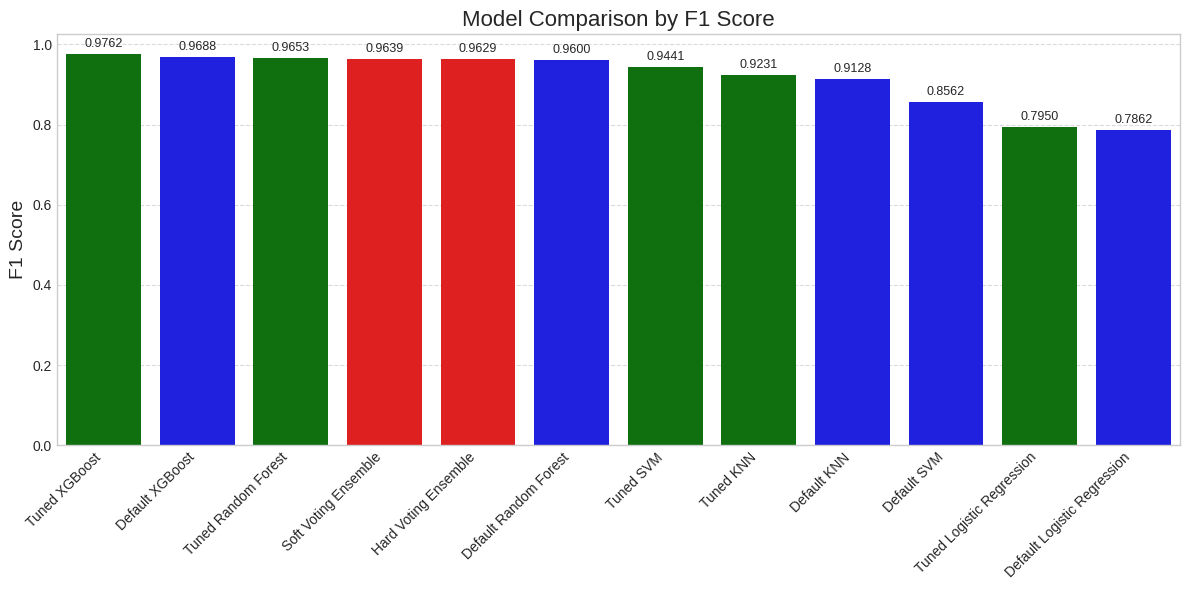

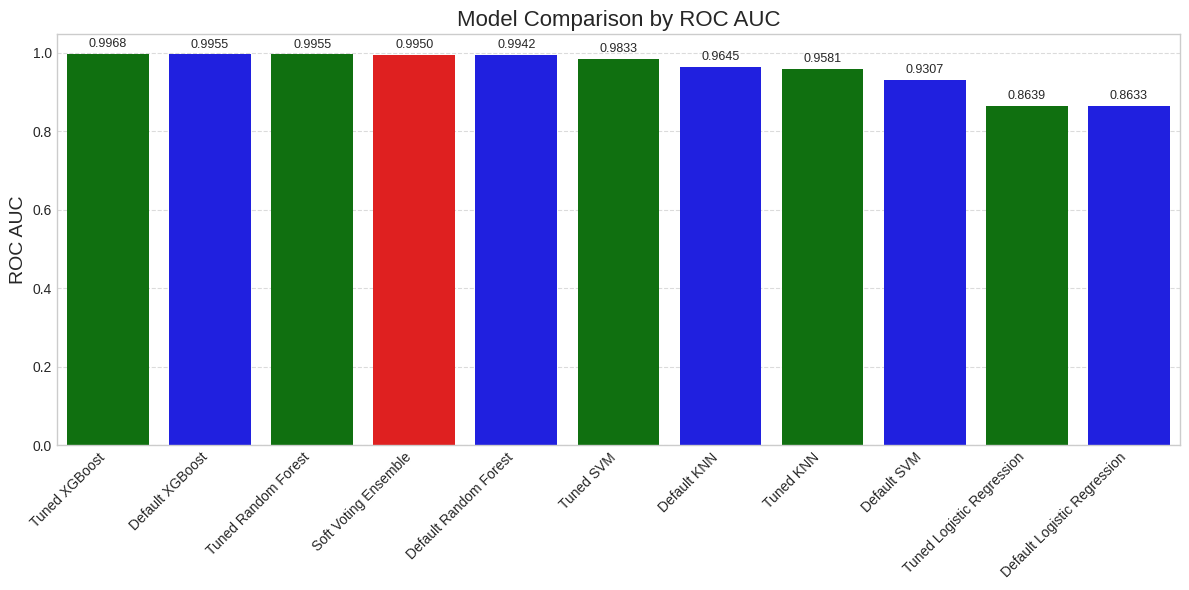

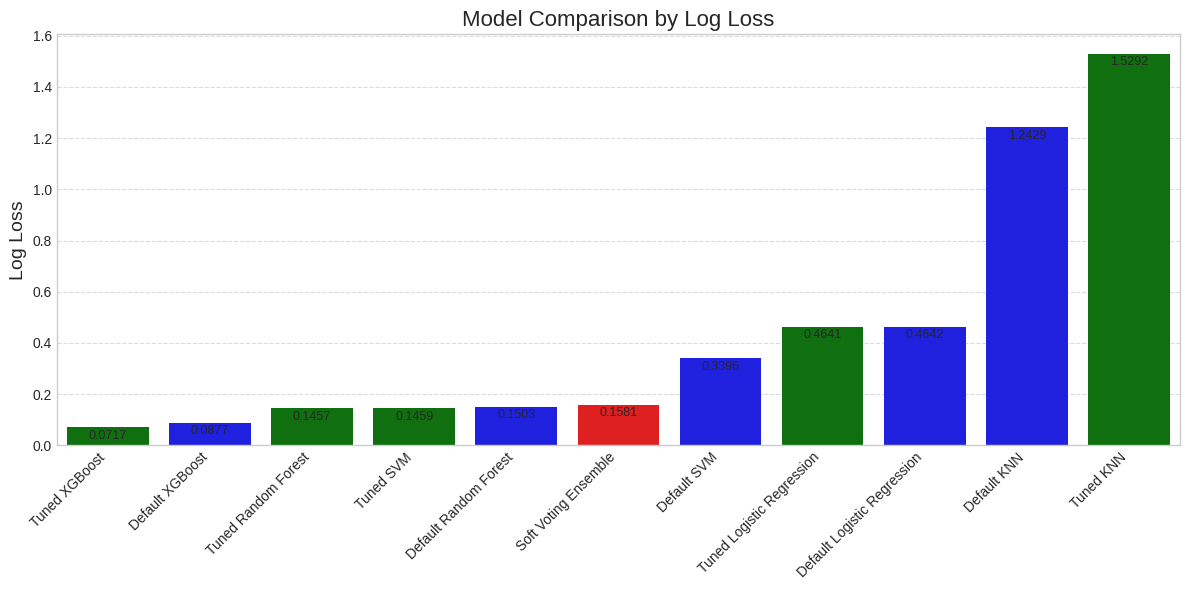

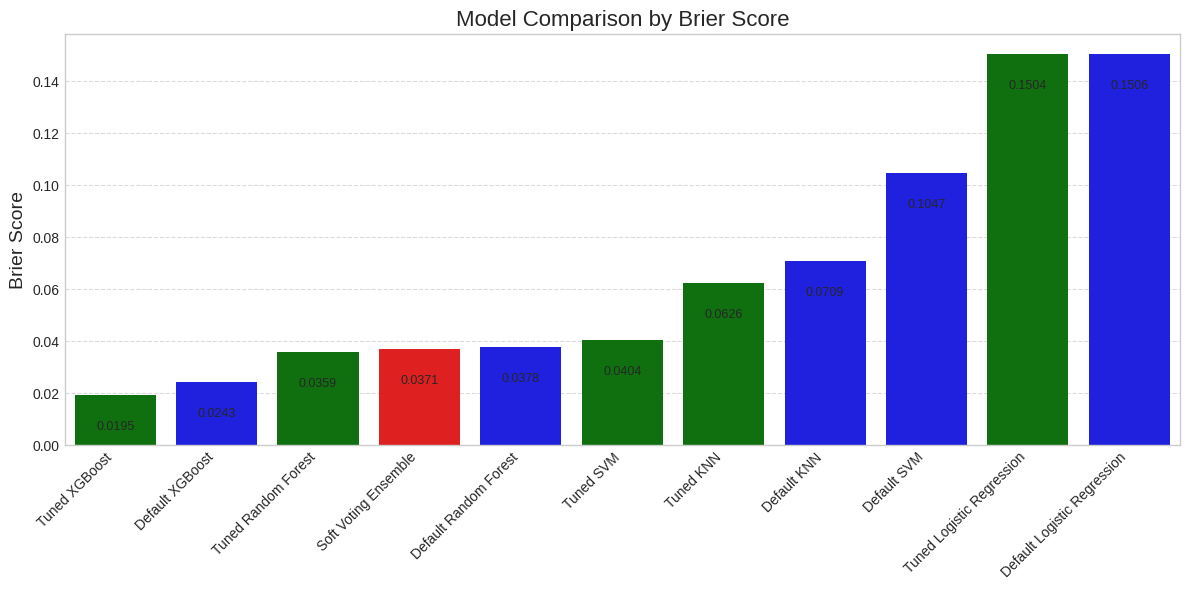

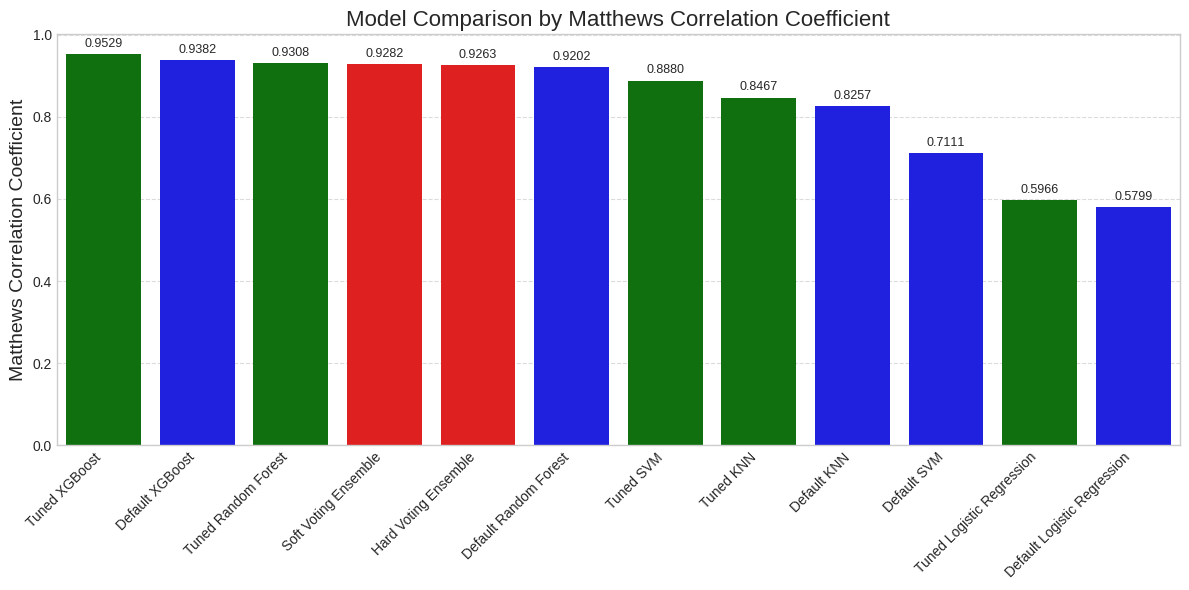

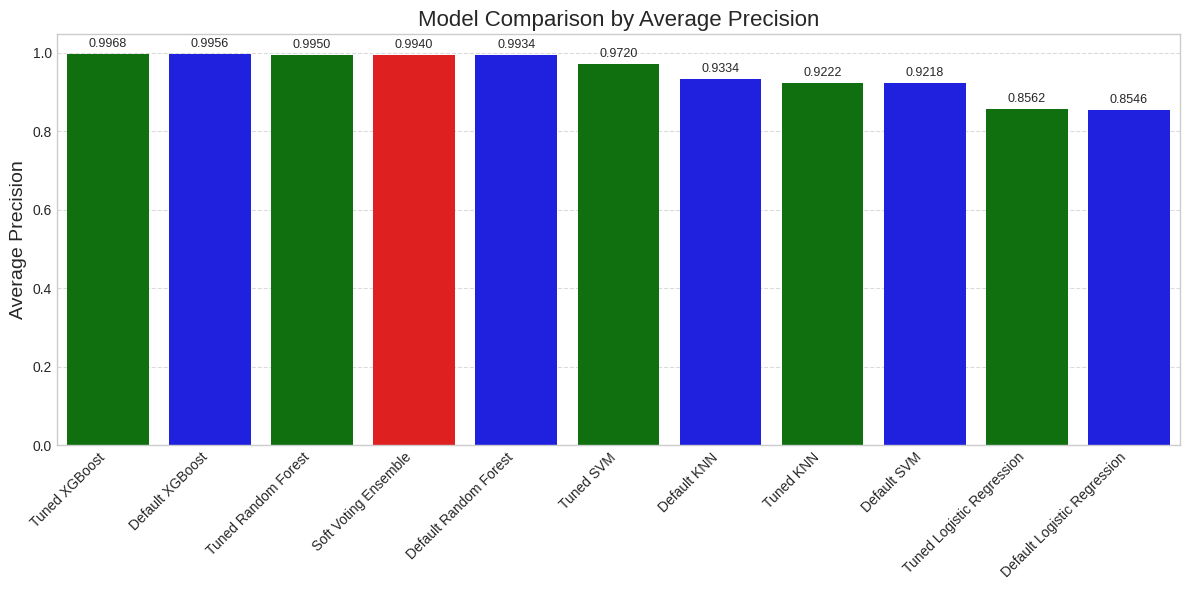

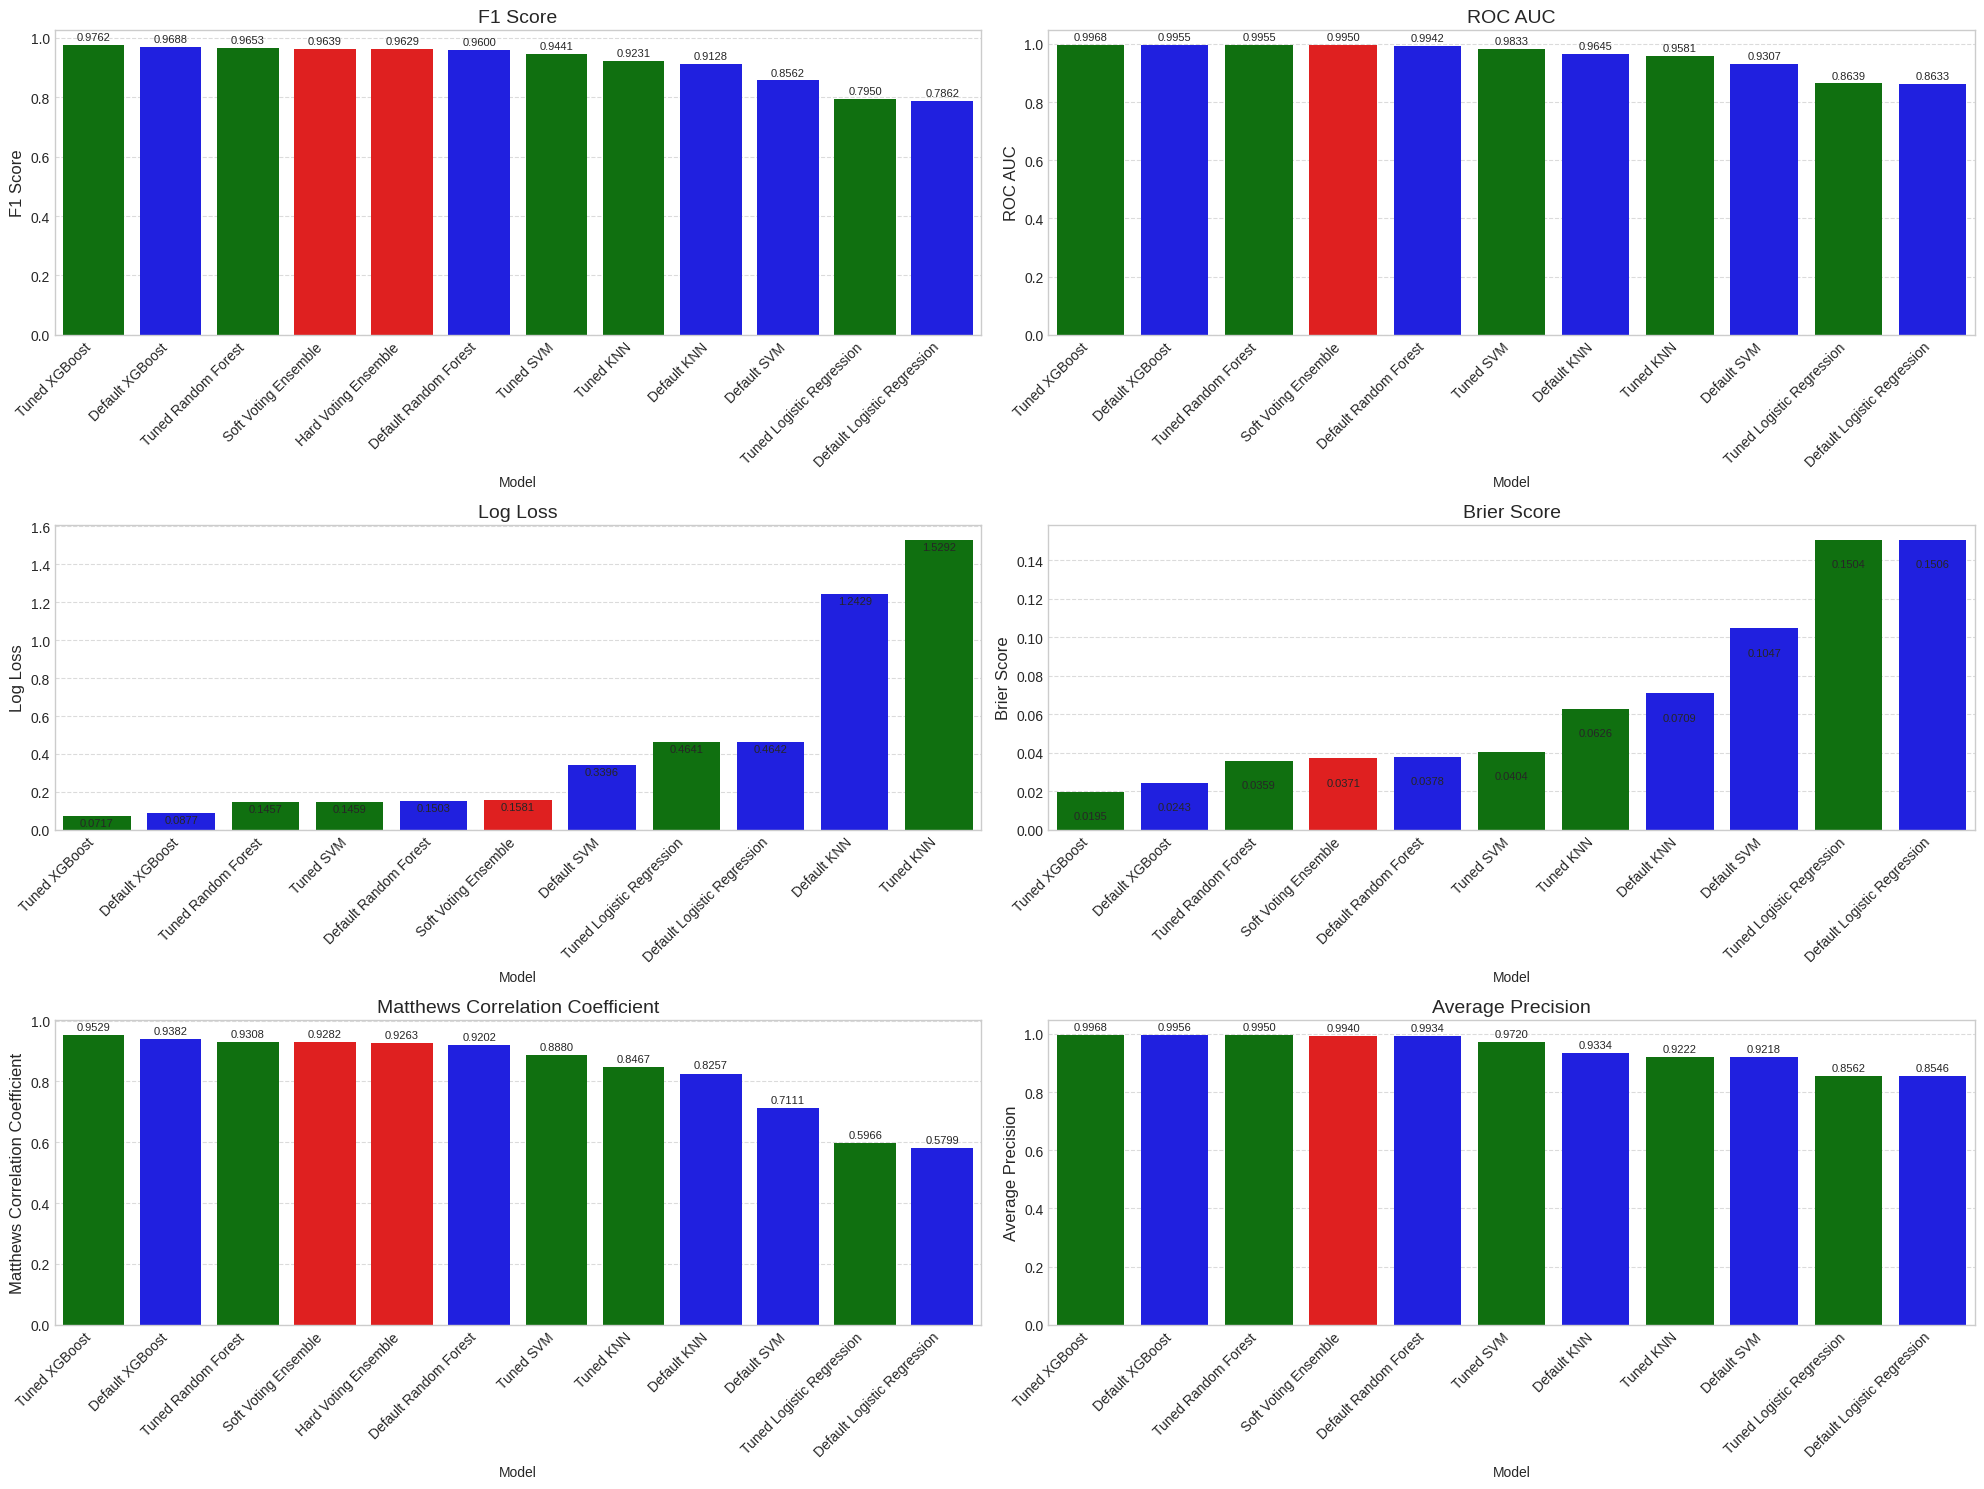


TOP 3 MODELS
Top 3 Models Based on Multiple Metrics:
1. Tuned XGBoost
   f1: 0.9762
   roc_auc: 0.9968
   mcc: 0.9529
   avg_precision: 0.9968
   log_loss: 0.0717
   brier_score: 0.0195

2. Default XGBoost
   f1: 0.9688
   roc_auc: 0.9955
   mcc: 0.9382
   avg_precision: 0.9956
   log_loss: 0.0877
   brier_score: 0.0243

3. Tuned Random Forest
   f1: 0.9653
   roc_auc: 0.9955
   mcc: 0.9308
   avg_precision: 0.9950
   log_loss: 0.1457
   brier_score: 0.0359



<Figure size 1000x800 with 0 Axes>

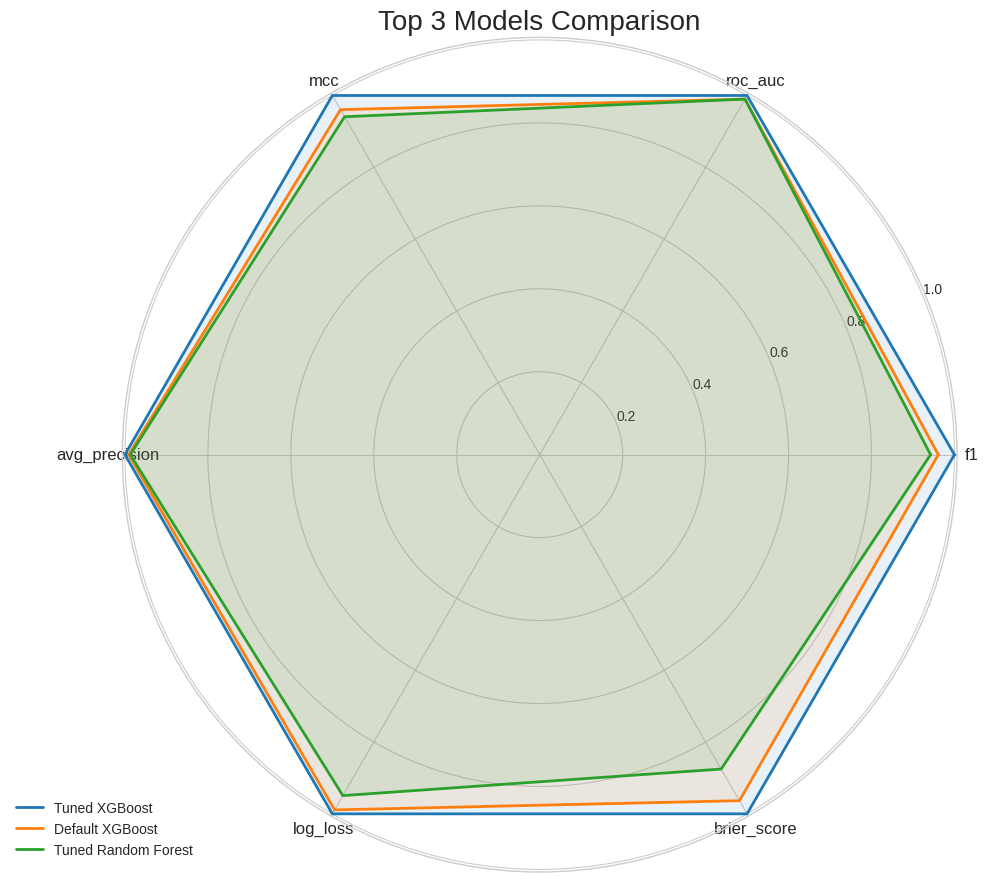

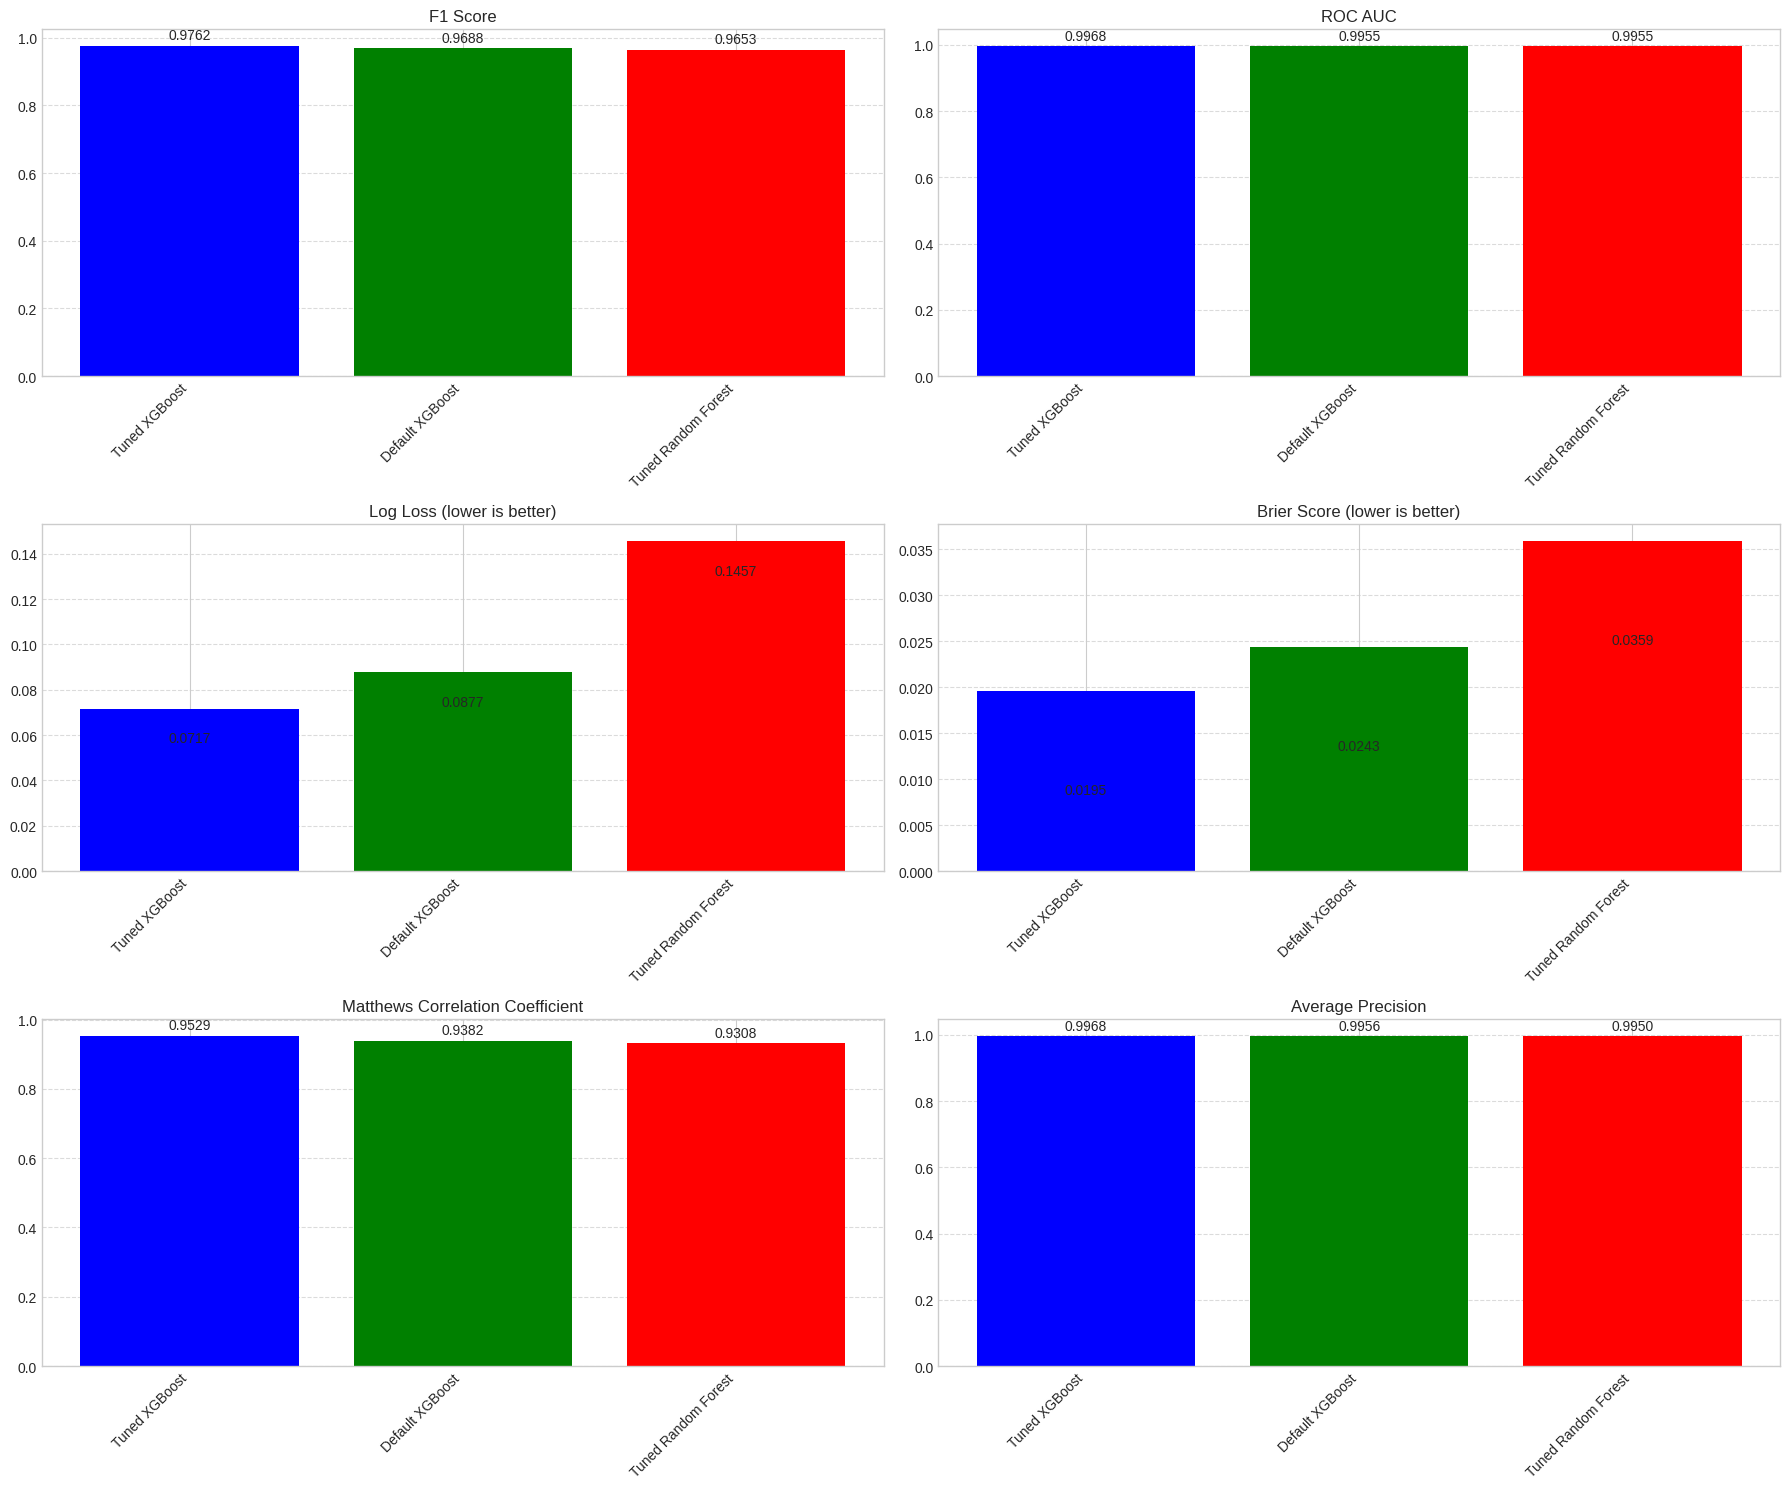


ALL METRICS VISUALIZATIONS AND CONFUSION MATRICES


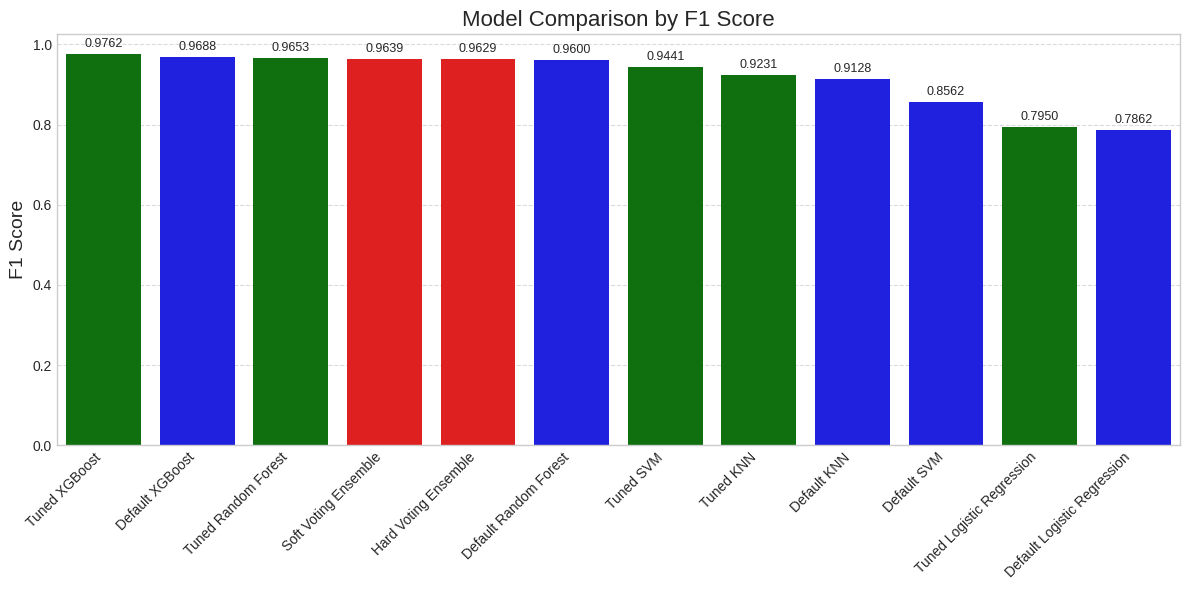

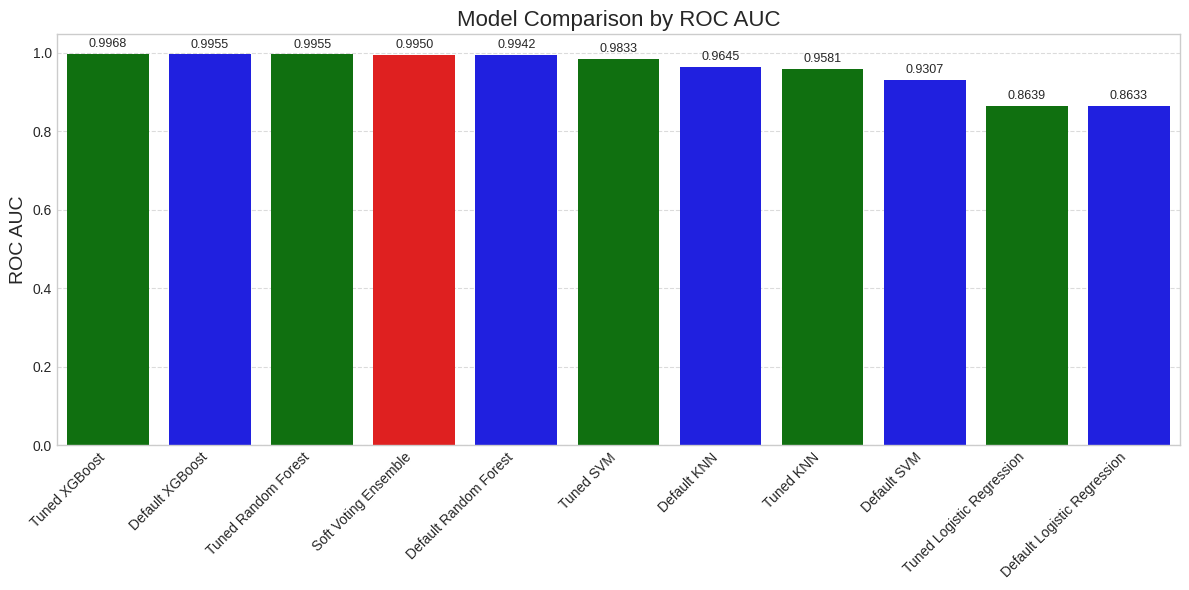

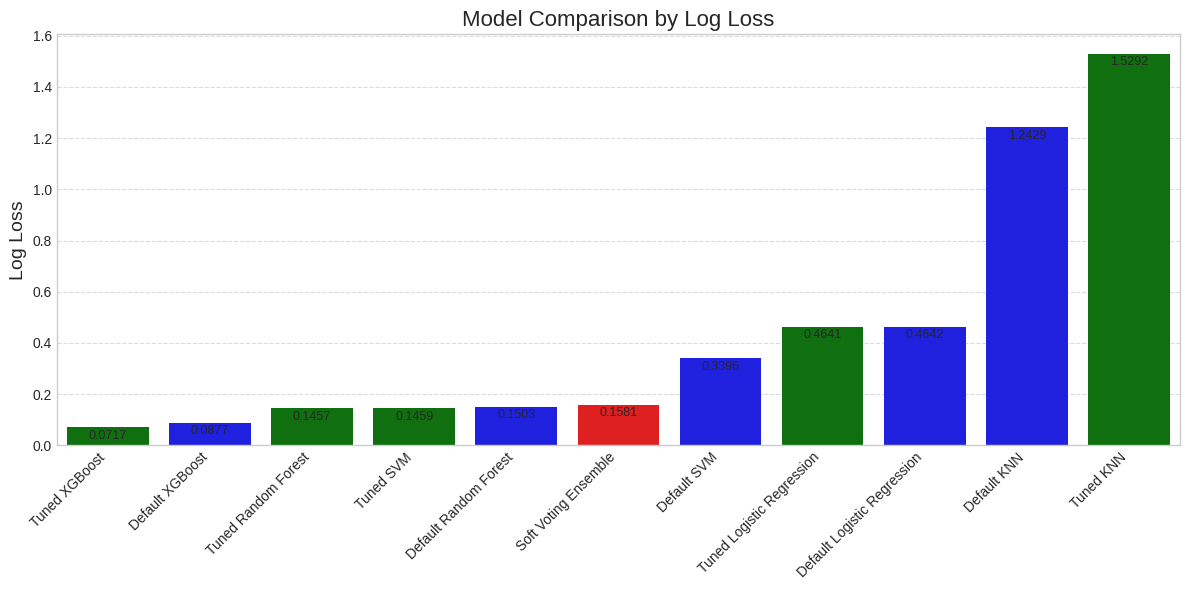

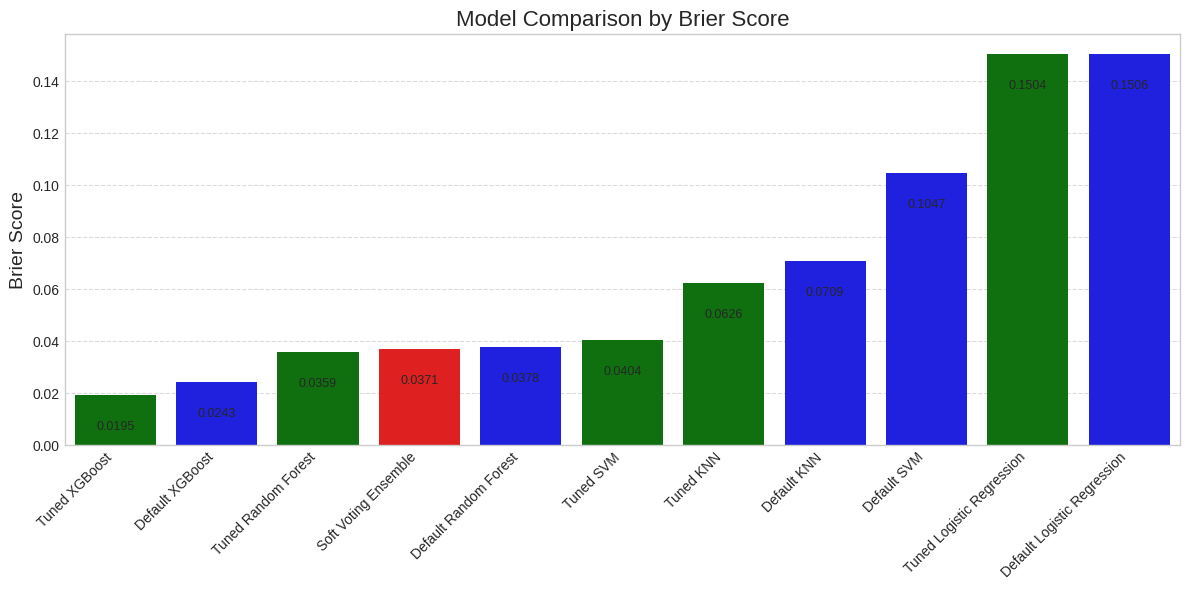

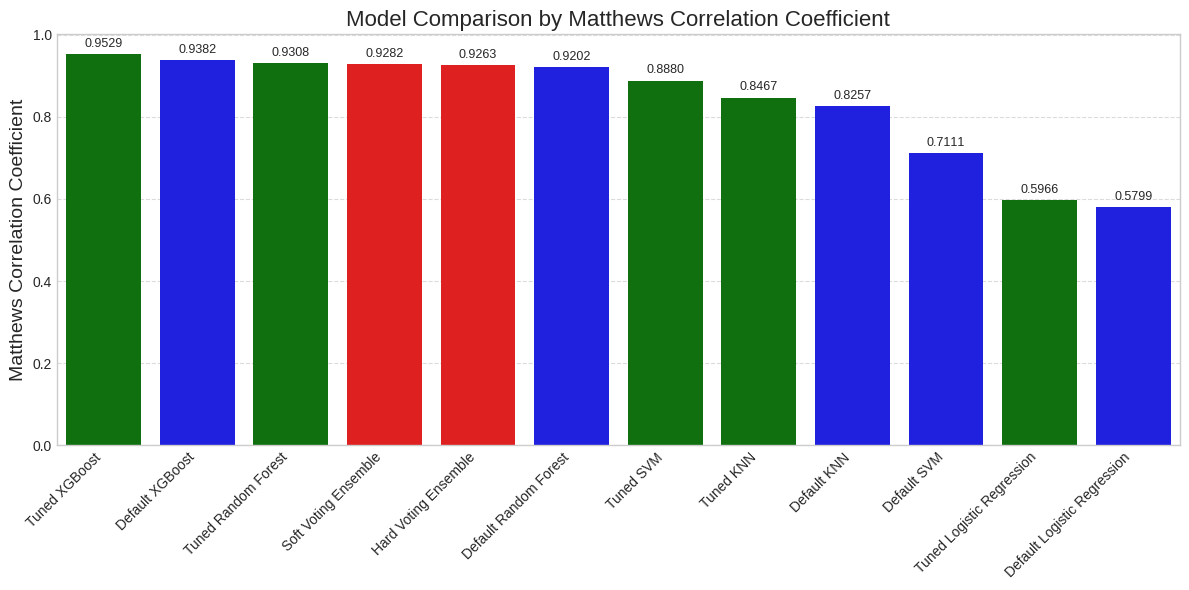

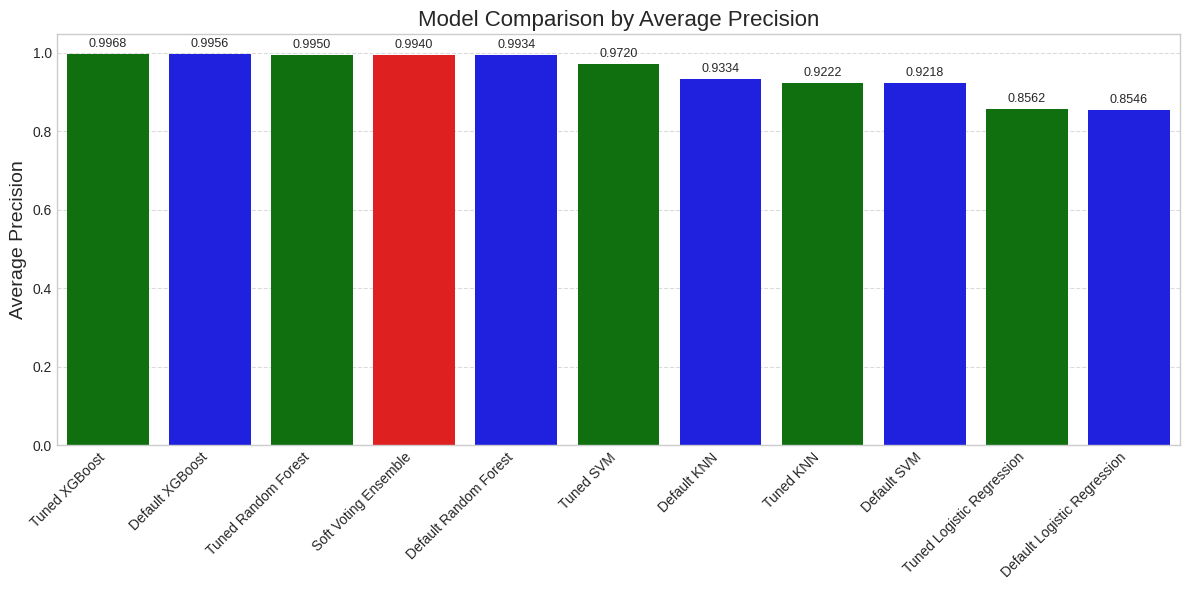


CONFUSION MATRIX VISUALIZATIONS


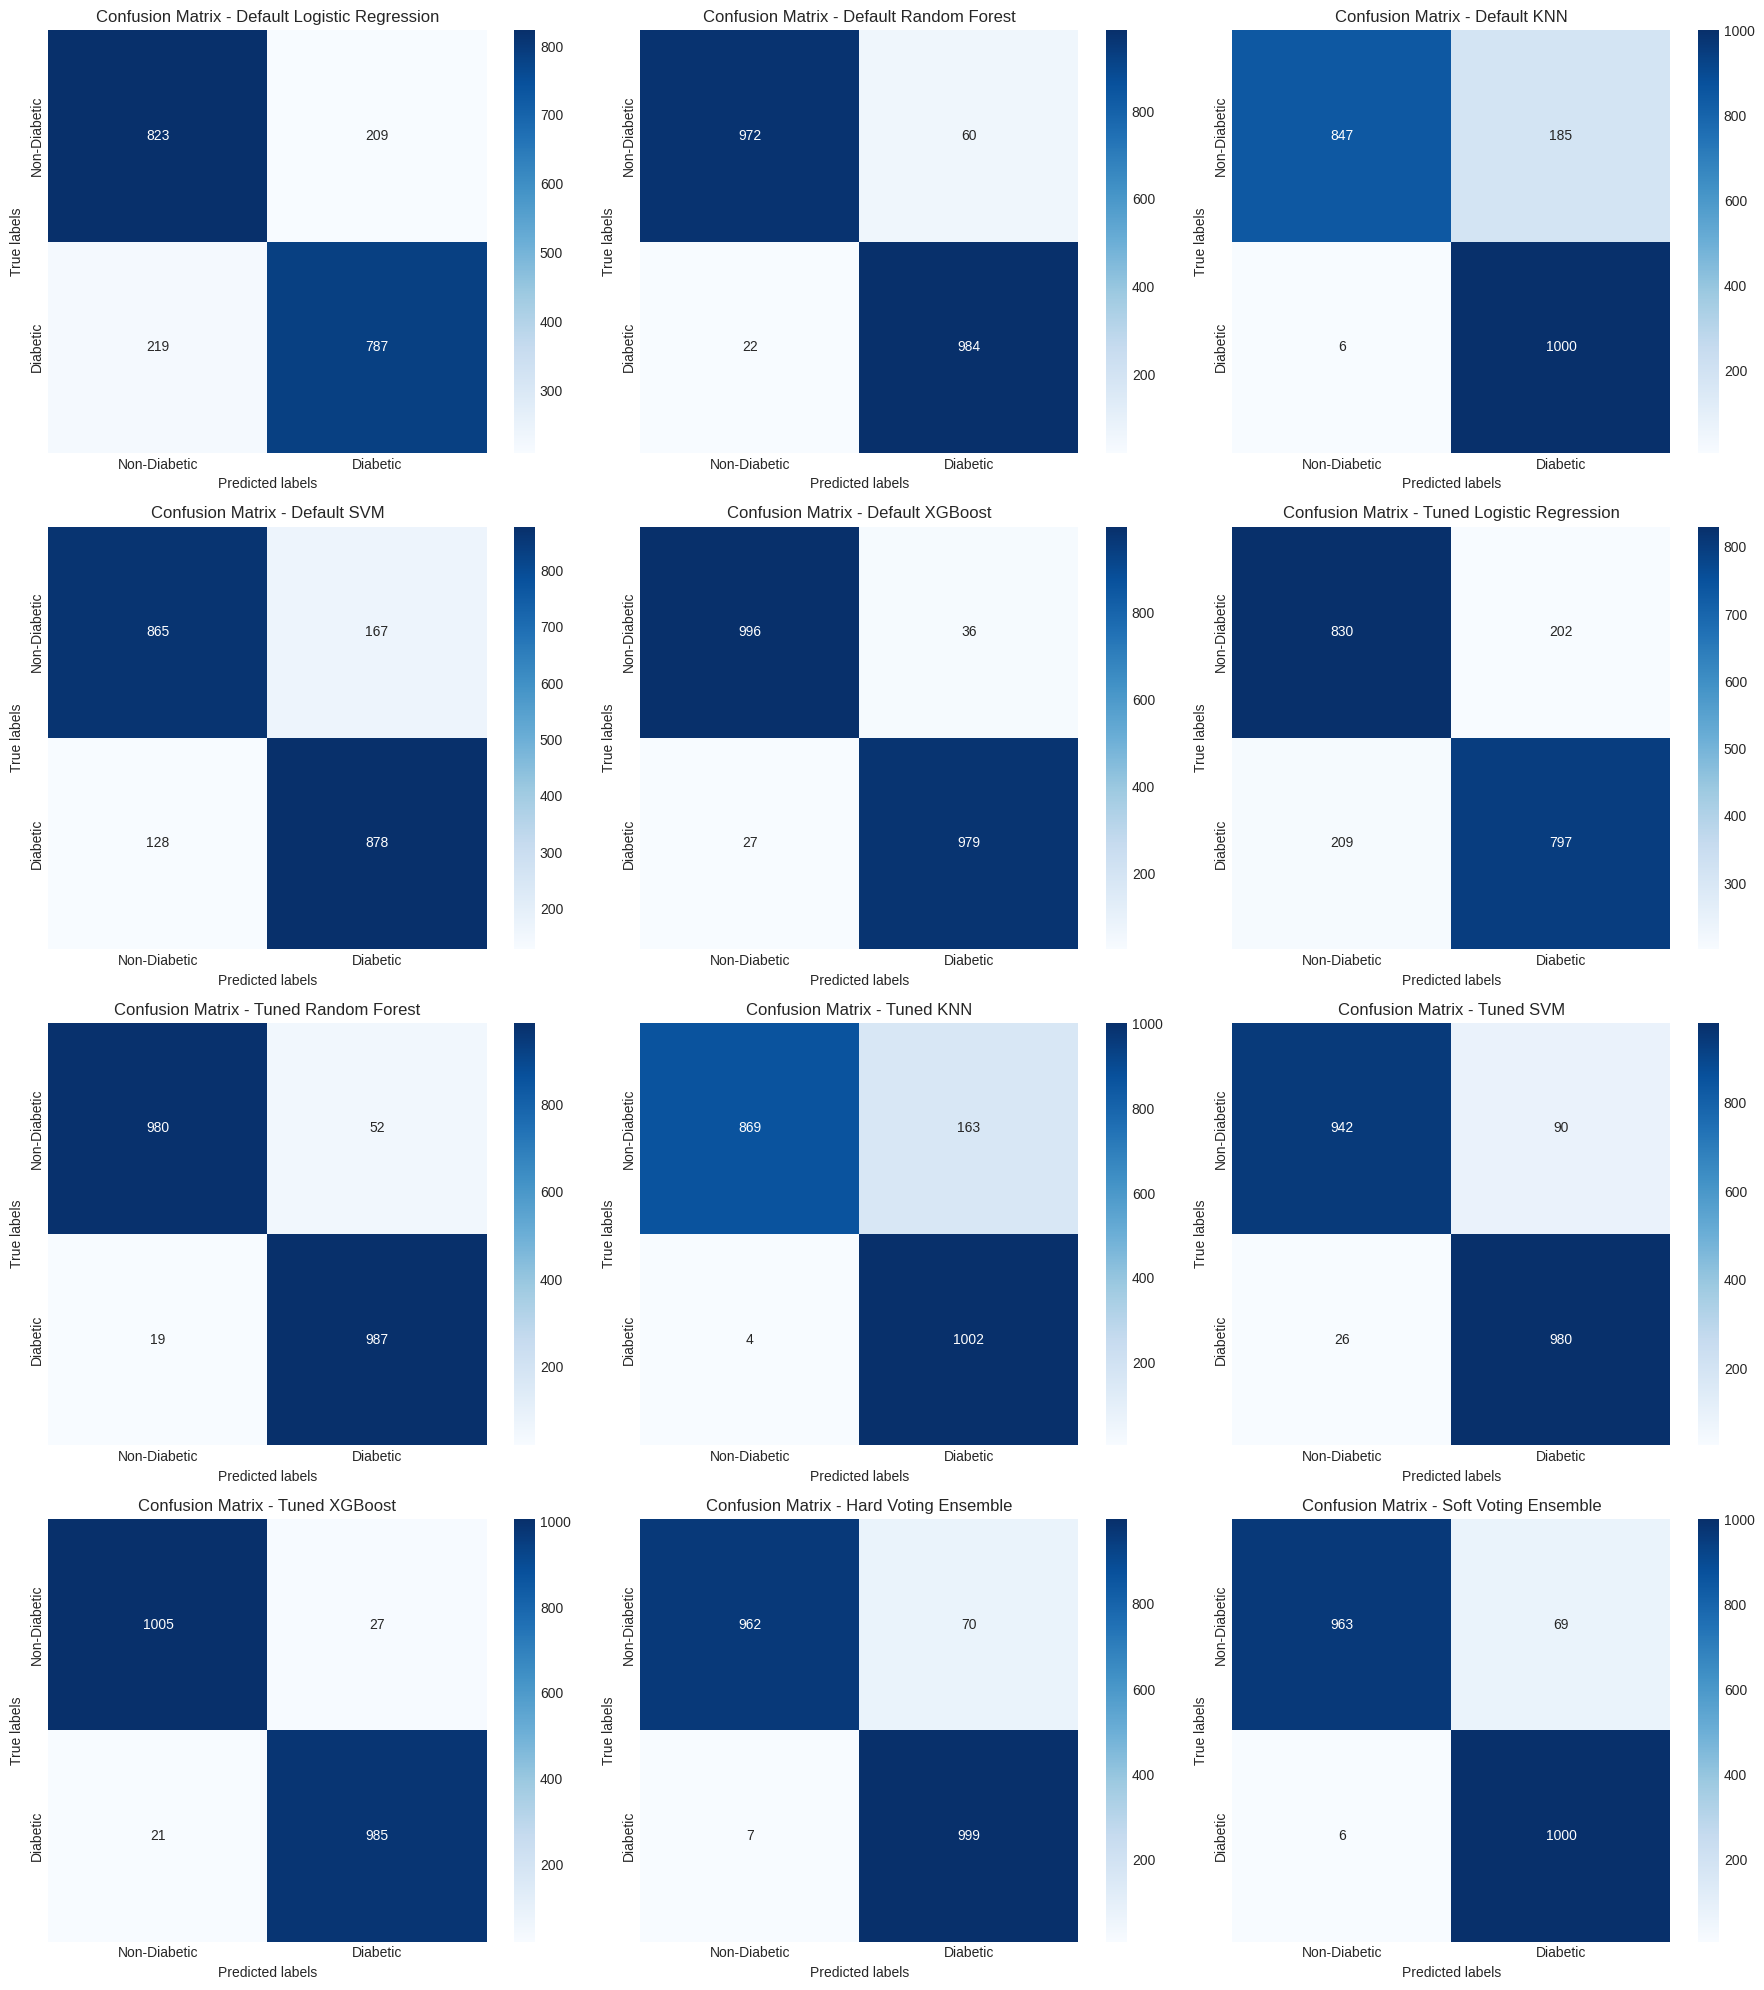


TOP 3 MODELS DETAILED VISUALIZATION


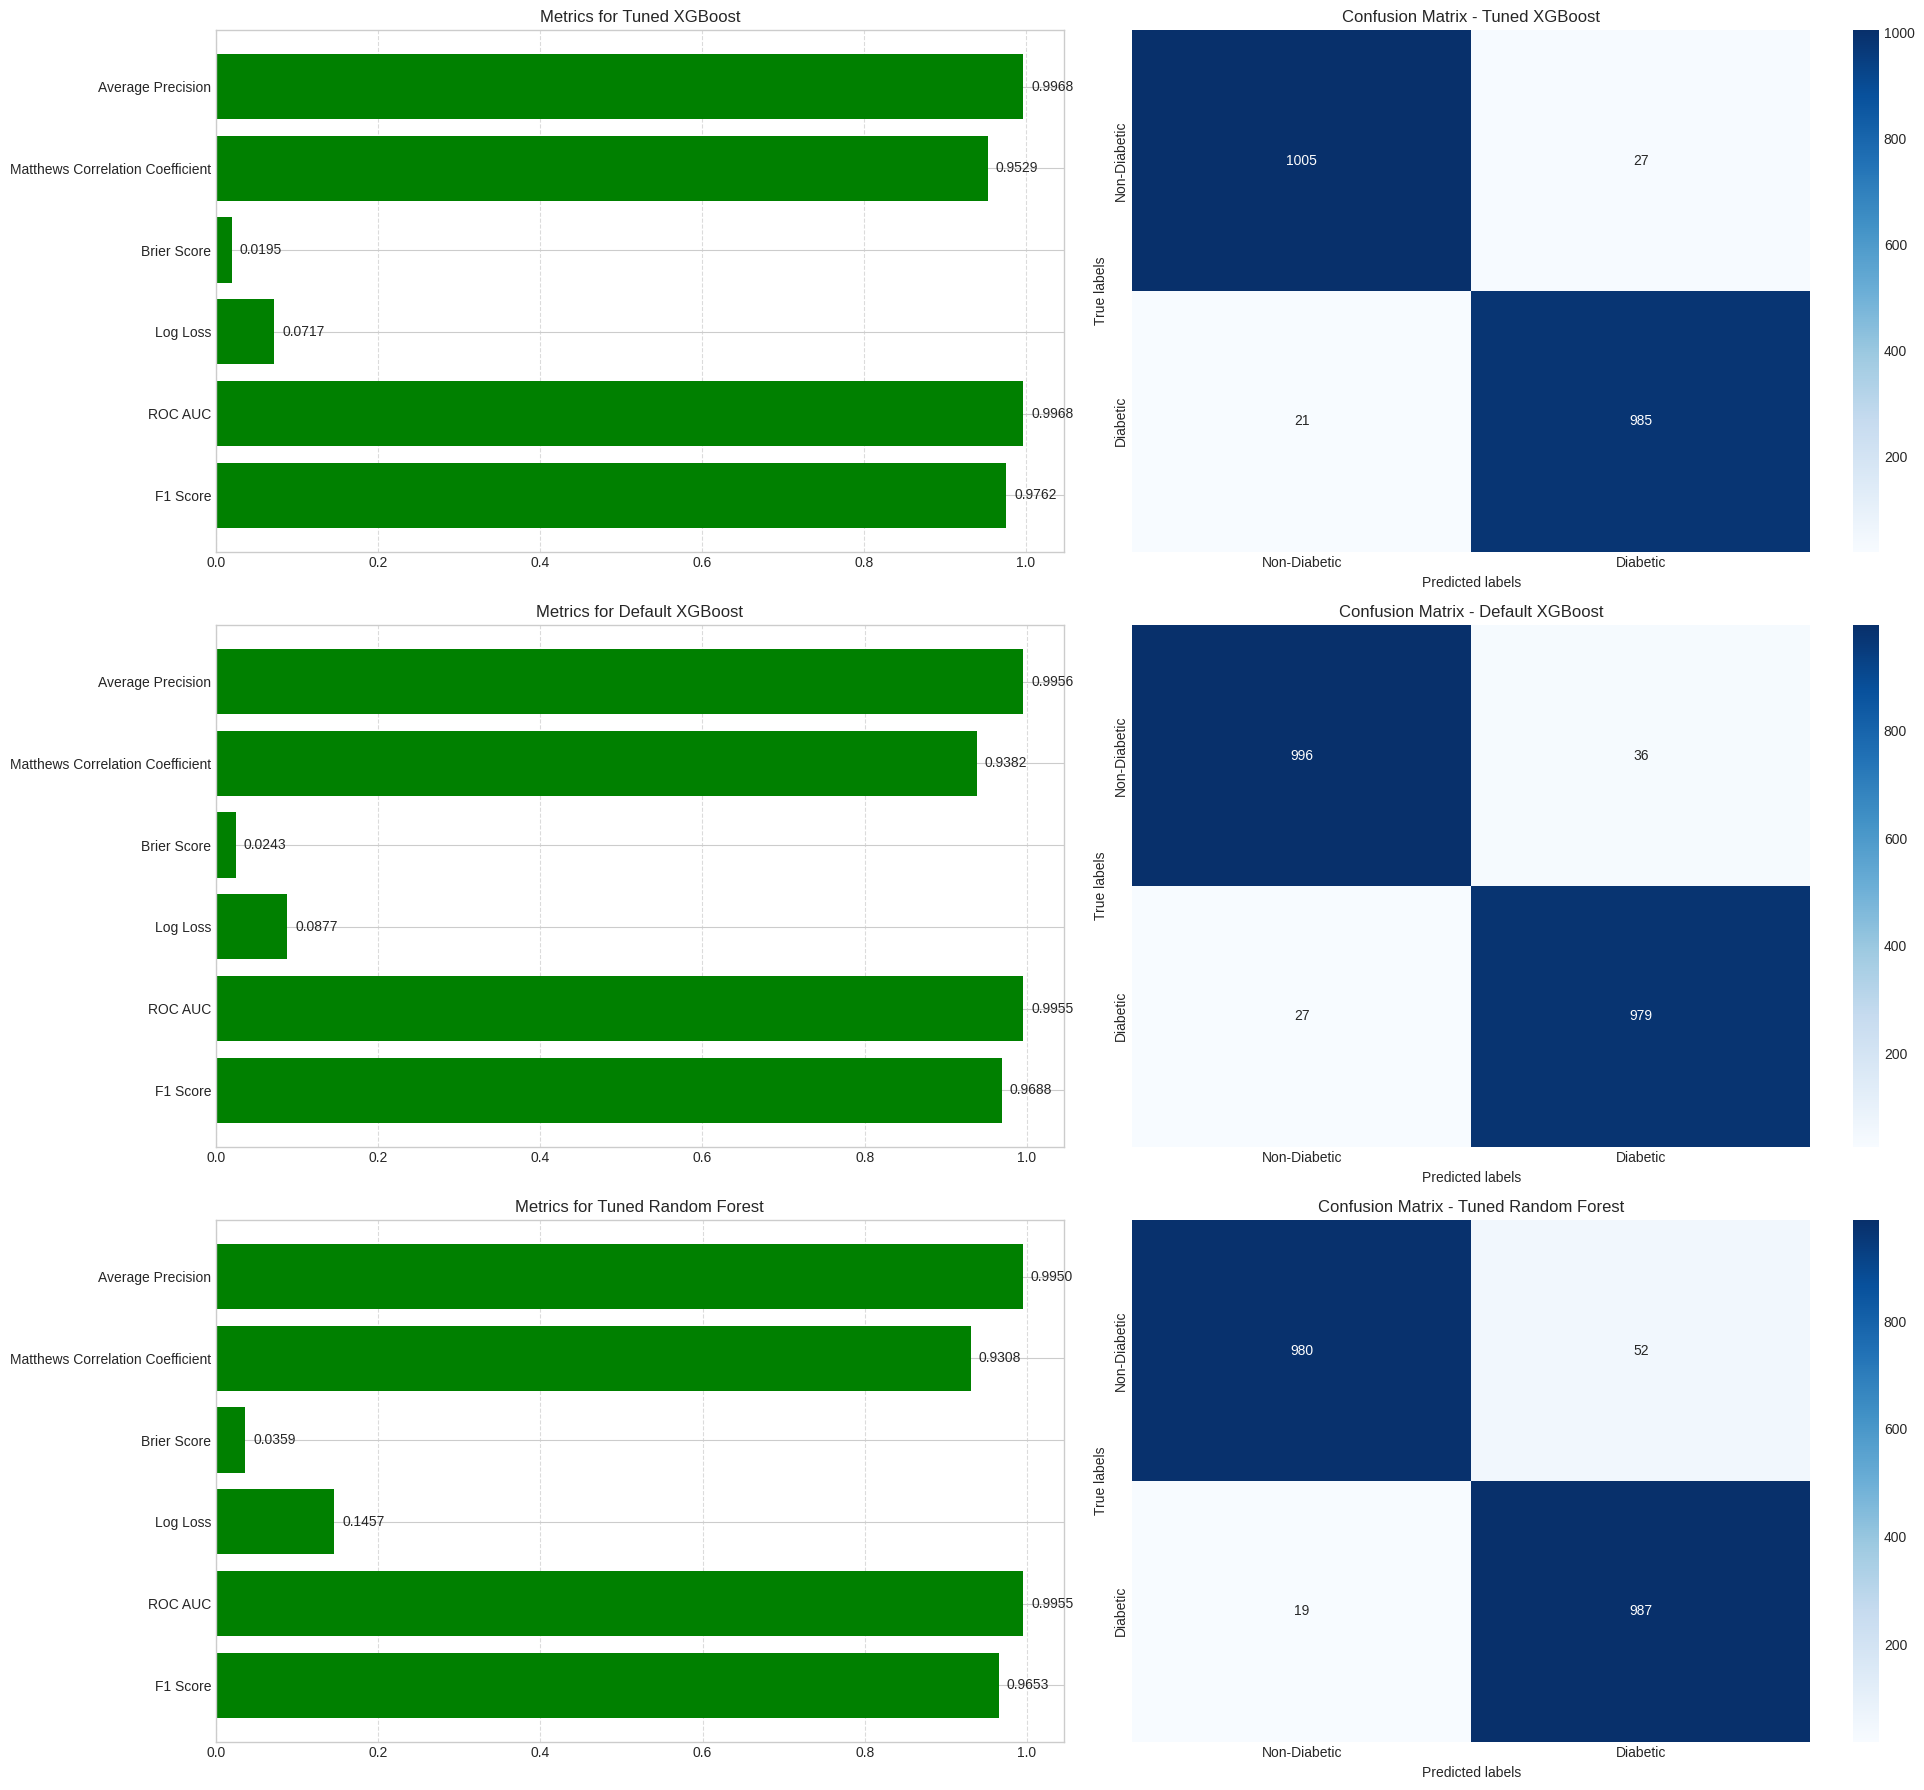


ANALYSIS COMPLETED


In [ ]:
# Main workflow
if __name__ == "__main__":
   # Train default models
   default_models = train_default_models(X_train, X_test, y_train, y_test)

   # Tune models
   print("\n" + "="*50)
   print("MODEL TUNING")
   print("="*50)

   lr_tuned = tune_logistic_regression(X_train, y_train)
   rf_tuned = tune_random_forest(X_train, y_train)
   knn_tuned = tune_knn(X_train, y_train)
   svm_tuned = tune_svm(X_train, y_train)
   xgb_tuned = tune_xgboost(X_train, y_train)

   # Evaluate tuned models
   print("\n" + "="*50)
   print("EVALUATING TUNED MODELS")
   print("="*50)

   tuned_models = {}

   lr_tuned, lr_tuned_metrics = evaluate_model(
       lr_tuned, X_train, X_test, y_train, y_test, "Tuned Logistic Regression"
   )
   tuned_models['Logistic Regression'] = (lr_tuned, lr_tuned_metrics)

   rf_tuned, rf_tuned_metrics = evaluate_model(
       rf_tuned, X_train, X_test, y_train, y_test, "Tuned Random Forest"
   )
   tuned_models['Random Forest'] = (rf_tuned, rf_tuned_metrics)

   knn_tuned, knn_tuned_metrics = evaluate_model(
       knn_tuned, X_train, X_test, y_train, y_test, "Tuned KNN"
   )
   tuned_models['KNN'] = (knn_tuned, knn_tuned_metrics)

   svm_tuned, svm_tuned_metrics = evaluate_model(
       svm_tuned, X_train, X_test, y_train, y_test, "Tuned SVM"
   )
   tuned_models['SVM'] = (svm_tuned, svm_tuned_metrics)

   xgb_tuned, xgb_tuned_metrics = evaluate_model(
       xgb_tuned, X_train, X_test, y_train, y_test, "Tuned XGBoost"
   )
   tuned_models['XGBoost'] = (xgb_tuned, xgb_tuned_metrics)

   # Create and evaluate ensemble models
   ensemble_models = create_ensembles(tuned_models, X_train, X_test, y_train, y_test)

   # Visualize metrics for all models
   print("\n" + "="*50)
   print("MODEL COMPARISON VISUALIZATIONS")
   print("="*50)

   # Plot individual metric comparisons
   plot_metric_comparison(default_models, tuned_models, ensemble_models, 'f1', 'F1 Score')
   plot_metric_comparison(default_models, tuned_models, ensemble_models, 'roc_auc', 'ROC AUC')
   plot_metric_comparison(default_models, tuned_models, ensemble_models, 'log_loss', 'Log Loss')
   plot_metric_comparison(default_models, tuned_models, ensemble_models, 'brier_score', 'Brier Score')
   plot_metric_comparison(default_models, tuned_models, ensemble_models, 'mcc', 'Matthews Correlation Coefficient')
   plot_metric_comparison(default_models, tuned_models, ensemble_models, 'avg_precision', 'Average Precision')

   # Plot all metrics in one figure
   plot_all_metrics(default_models, tuned_models, ensemble_models)

   # Find and visualize top 3 models
   top_3_models = find_top_3_models(default_models, tuned_models, ensemble_models)

   # Visualize all metrics in bar charts (satu chart per metrik)
   visualize_all_metrics_and_confusion_matrices(default_models, tuned_models, ensemble_models)

   # Visualize top 3 models with detailed metrics and confusion matrices
   visualize_top_models(top_3_models, default_models, tuned_models, ensemble_models)

   print("\n" + "="*50)
   print("ANALYSIS COMPLETED")
   print("="*50)

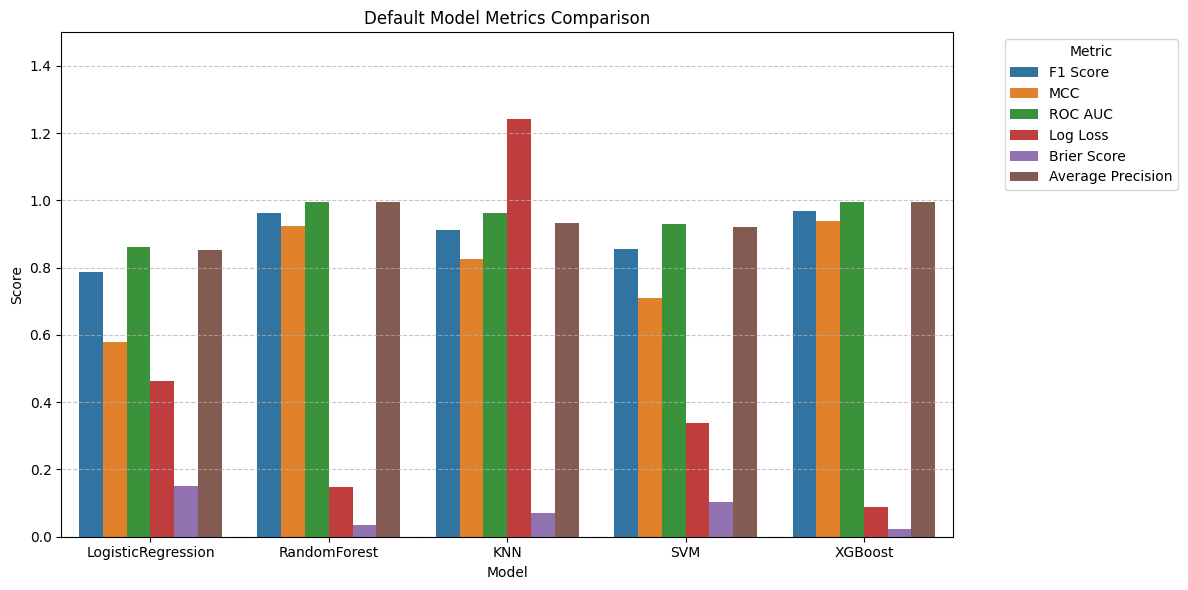

In [ ]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import seaborn as sns

# # Data dari evaluasi default model
# models = ['LogisticRegression', 'RandomForest', 'KNN', 'SVM', 'XGBoost']
# metrics_data = {
#     'F1 Score':         [0.786, 0.962, 0.912, 0.856, 0.968],
#     'MCC':              [0.579, 0.925, 0.825, 0.711, 0.938],
#     'ROC AUC':          [0.863, 0.995, 0.964, 0.930, 0.995],
#     'Log Loss':         [0.464, 0.147, 1.242, 0.339, 0.087],
#     'Brier Score':      [0.150, 0.036, 0.070, 0.104, 0.024],
#     'Average Precision':[0.854, 0.994, 0.933, 0.921, 0.995]
# }

# # Konversi ke DataFrame
# df = pd.DataFrame(metrics_data, index=models)
# df = df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
# df.rename(columns={'index': 'Model'}, inplace=True)

# # Visualisasi
# plt.figure(figsize=(12, 6))
# sns.barplot(data=df, x='Model', y='Score', hue='Metric')
# plt.title('Default Model Metrics Comparison')
# plt.ylim(0, 1.5)  # Diperbesar hingga 1.5
# plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()


import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data dari evaluasi default model
models = ['LogisticRegression', 'RandomForest', 'KNN', 'SVM', 'XGBoost']
metrics_data = {
    'F1 Score':         [0.786, 0.962, 0.912, 0.856, 0.968],
    'MCC':              [0.579, 0.925, 0.825, 0.711, 0.938],
    'ROC AUC':          [0.863, 0.995, 0.964, 0.930, 0.995],
    'Log Loss':         [0.464, 0.147, 1.242, 0.339, 0.087],
    'Brier Score':      [0.150, 0.036, 0.070, 0.104, 0.024],
    'Average Precision':[0.854, 0.994, 0.933, 0.921, 0.995]
}

# Konversi ke DataFrame
df = pd.DataFrame(metrics_data, index=models)
df = df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
df.rename(columns={'index': 'Model'}, inplace=True)

# Visualisasi
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Model', y='Score', hue='Metric')
plt.title('Default Model Metrics Comparison')
plt.ylim(0, 1.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Garis bantu horizontal
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


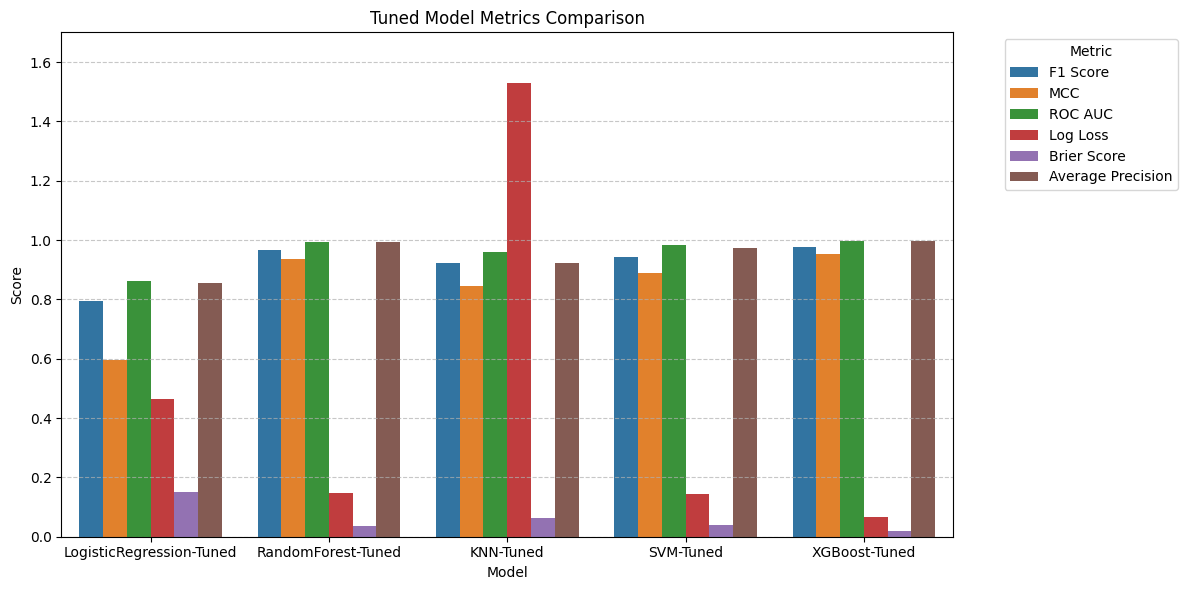

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data dari evaluasi default model
models = ['LogisticRegression-Tuned', 'RandomForest-Tuned', 'KNN-Tuned', 'SVM-Tuned', 'XGBoost-Tuned']
metrics_data = {
    'F1 Score':         [0.795, 0.968, 0.923, 0.944, 0.975],
    'MCC':              [0.596, 0.936, 0.846, 0.888, 0.952],
    'ROC AUC':          [0.863, 0.995, 0.958, 0.983, 0.997],
    'Log Loss':         [0.464, 0.147, 1.529, 0.145, 0.068],
    'Brier Score':      [0.150, 0.036, 0.062, 0.040, 0.019],
    'Average Precision':[0.856, 0.994, 0.922, 0.972, 0.997]
}

# Konversi ke DataFrame
df = pd.DataFrame(metrics_data, index=models)
df = df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
df.rename(columns={'index': 'Model'}, inplace=True)

# Visualisasi
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Model', y='Score', hue='Metric')
plt.title('Tuned Model Metrics Comparison')
plt.ylim(0, 1.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Garis bantu horizontal
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


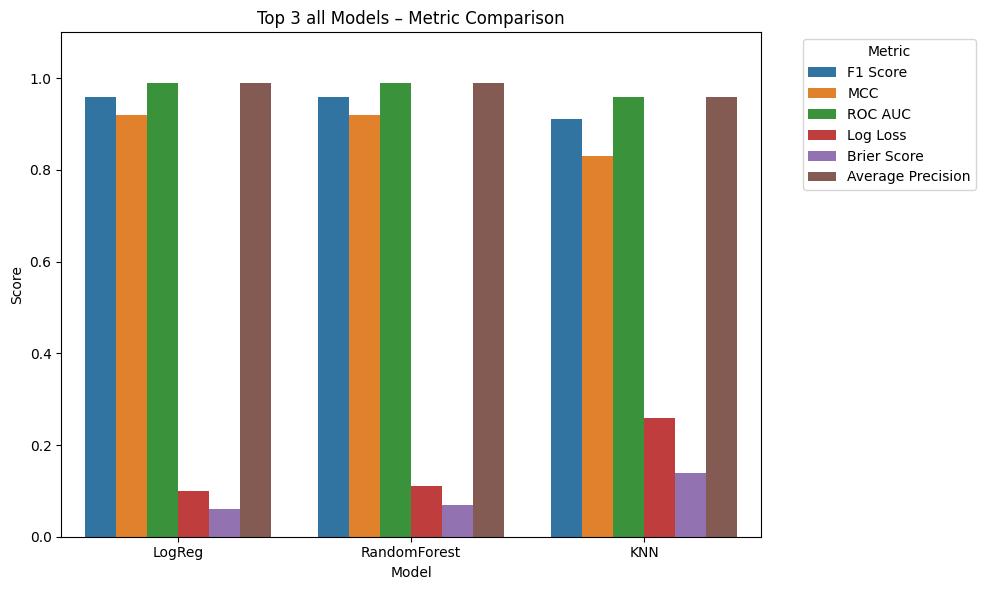

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data dari evaluasi default model
models = ['LogReg', 'RandomForest', 'KNN', 'SVM', 'XGBoost']
metrics_data = {
    'F1 Score':         [0.96, 0.96, 0.91, 0.86, 0.79],
    'MCC':              [0.92, 0.92, 0.83, 0.74, 0.59],
    'ROC AUC':          [0.99, 0.99, 0.96, 0.93, 0.87],
    'Log Loss':         [0.10, 0.11, 0.26, 0.36, 0.52],
    'Brier Score':      [0.06, 0.07, 0.14, 0.21, 0.31],
    'Average Precision':[0.99, 0.99, 0.96, 0.91, 0.85]
}

# Konversi ke DataFrame dan hitung rata-rata setiap model (semua metrik dianggap semakin besar semakin baik, jadi untuk Log Loss & Brier Score kita balik dulu)
df_raw = pd.DataFrame(metrics_data, index=models)

# Balik metrik yang semakin kecil semakin bagus
df_raw['Log Loss'] = 1 - df_raw['Log Loss']
df_raw['Brier Score'] = 1 - df_raw['Brier Score']

# Hitung rata-rata skor untuk ranking
df_raw['Mean Score'] = df_raw.mean(axis=1)
top3_models = df_raw.sort_values(by='Mean Score', ascending=False).head(3).index.tolist()

# Buat ulang dataframe untuk plotting (tanpa membalik metrik lagi)
df_plot = pd.DataFrame(metrics_data, index=models)
df_plot = df_plot.loc[top3_models]
df_plot = df_plot.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
df_plot.rename(columns={'index': 'Model'}, inplace=True)

# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Model', y='Score', hue='Metric')
plt.title('Top 3 all Models – Metric Comparison')
plt.ylim(0, 1.1)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


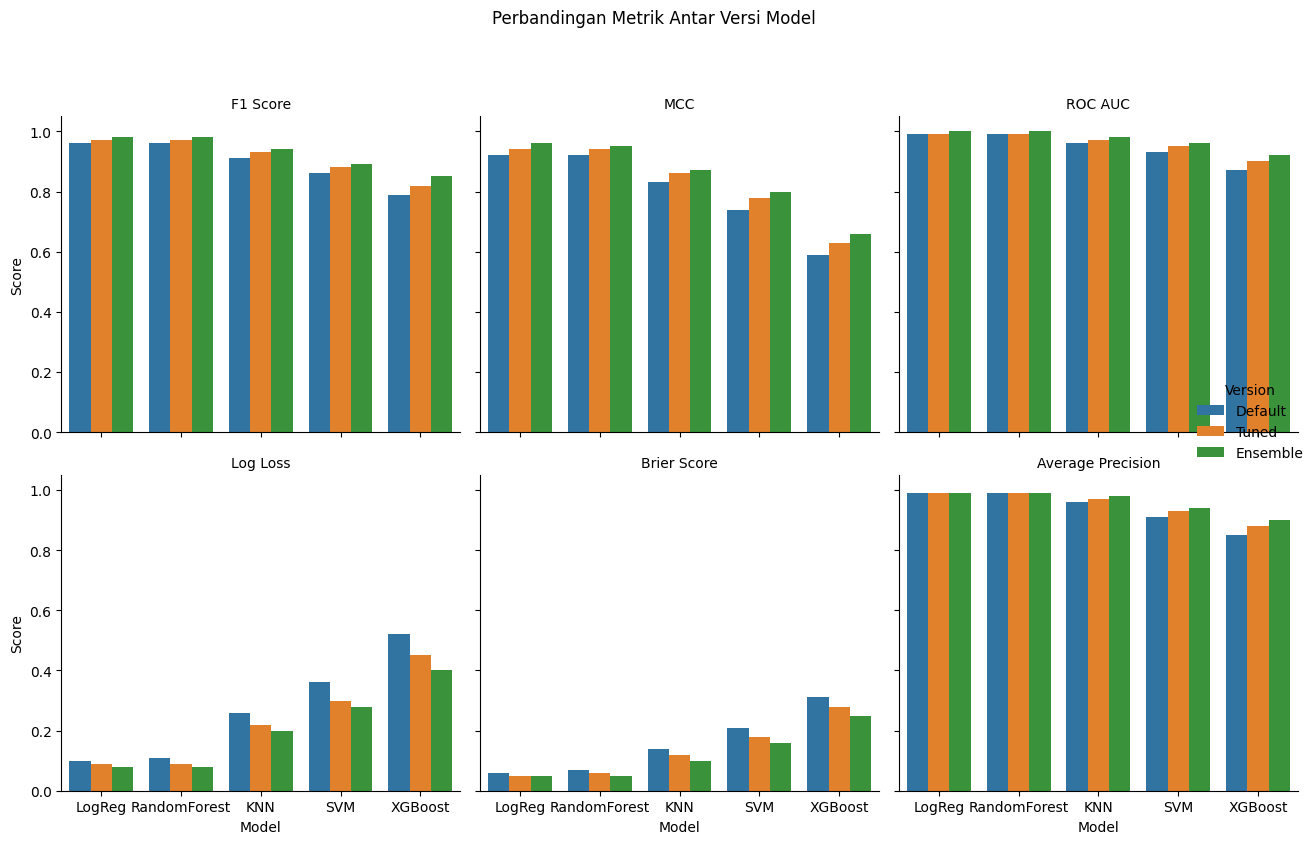